# Return curves of each option and env reward

In [2]:
# get data - download and store locally 
import wandb
import os
from dotenv import load_dotenv
# load environment variables from .env file
load_dotenv()
# use .env for the api key
api_key =  os.getenv("WANDB_API_KEY")
api = wandb.Api(api_key=api_key)

In [3]:
import pandas as pd
import numpy as np


def get_algorithm_from_name(name):
    if "ppo" in name:
        return "PPO (baseline)"
    elif "baseline" in name:
        return "HPQN (baseline)"
    elif "pre" in name:
        return "Pretrained"
    elif "comb" in name:
        # return "Soft meta-policy"
        return "LENS (neurosym.)"
    elif "llm" in name:
        # return "Fixed meta-policy"
        return "LENS (symbolic)"
    elif "hier" in name:
        return "LENS (neural)"
    elif "pqn" in name:
        return "PQN (baseline)"
    else:
        return "Unknown"

In [4]:
# import time

def get_run_data(runs, craftax=False):
    data = []
    for run_id in runs:
        run = api.run(runs[run_id])
        print("quering run: ", run.id)
        env_name = run.name.split("_")[-1]
        alg_name = run.name.split("_")[0]
        run_data= run.history()
        # print("run data keys: ", run_data.keys())
        # run_data_full = run.history()
        seeds = list(set([key.split("/")[0] for key in run_data.keys() if "rng" in key]))
        if env_name.lower() == "kangaroo" and alg_name.lower() == "ppo":
            # remove the seed with rng1797259609, as it is a weird outlier 
            seeds = [seed for seed in seeds if seed != "rng1797259609"]

        # print all keys that have rng928981903 in name
        # TODO: Remove, not necessary anymore (I think)
        key_list = [key for key in run_data.keys() if "test" in key]
        retries = 0
        while len(key_list) == 0:
            # time.sleep(2)  # wait for 5 seconds before retrying
            if retries > 10:
                print("No test keys found after 10 retries, breaking...")
                break
            print("No test keys found, retrying...")
            run = api.run(runs[run_id])
            run_data = run.history()
            key_list = [key for key in run_data.keys() if "test" in key]
            retries += 1

        # key_list = ["returned_episode_env_returns", "returned_episode_returns_0", "returned_episode_returns_1", "returned_episode_returns_2", "test/returned_episode_env_returns", "test_modif/returned_episode_env_returns"]
        # key_list = [seed + "/" + key for seed in seeds for key in key_list]
        # key_list.append("_step")
        # run_data = run_data_full.loc[:, key_list]

        # x_data = run_data["_step"].to_numpy() / 1000
        env_key = "env_step" if "hier" not in run.name else "env_step_0"
        # modif = "modif" if alg_name.lower() == "ppo" else "test_modif"
        modif = "test_modif" 
        x_data = run_data[env_key].to_numpy()
        def get_seed_data(seed):
            env_ret = run_data[seed + "/returned_episode_env_returns"].to_numpy()
            # env_ret = np.where(env_ret is None, np.nan, env_ret)
            test_env_ret = run_data[seed + "/test/returned_episode_env_returns"].to_numpy()
            # count non-nan values
            # replace any None with np.nan
            # test_env_ret = np.where(test_env_ret is None, np.nan, test_env_ret)
            # print(test_env_ret)
            # print(f"Seed {seed} has {np.count_nonzero(~np.isnan(test_env_ret))} non-nan values in test env returns")
            modif_test_env_ret = run_data[seed + f"/{modif}/returned_episode_env_returns"].to_numpy()
            if craftax:
                score = run_data[seed + "/score"].to_numpy()
                test_score = run_data[seed + "/test/score"].to_numpy()


            # opt_rets = {}
            opt_rets = []
            match env_name.lower():
                case "pong":
                    option_strs = ["returned_episode_returns_0", "returned_episode_returns_1", "returned_episode_returns_2"]
                case "breakout":
                    option_strs = ["returned_episode_returns_0", "returned_episode_returns_1", "returned_episode_returns_2"]
                case "freeway":
                    option_strs = ["returned_episode_returns_0", "returned_episode_returns_1"]
                case "kangaroo":
                    option_strs = ["returned_episode_returns_0", "returned_episode_returns_1", "returned_episode_returns_2", "returned_episode_returns_3", "returned_episode_returns_4", "returned_episode_returns_5"]
                case "seaquest":
                    option_strs = ["returned_episode_returns_0", "returned_episode_returns_1", "returned_episode_returns_2", "returned_episode_returns_3", "returned_episode_returns_4", "returned_episode_returns_5", "returned_episode_returns_6"]
                case "craftax":
                    option_strs = ["returned_episode_returns_0", "returned_episode_returns_1", "returned_episode_returns_2"]
            if craftax:
                    option_strs = ["returned_episode_returns_0", "returned_episode_returns_1", "returned_episode_returns_2", "returned_episode_returns_3", "returned_episode_returns_4"]
            for opt_str in option_strs:
                ret = run_data[seed + "/" + opt_str].to_numpy()
                test_ret = run_data[seed + "/test/" + opt_str].to_numpy()
                if not craftax:
                    modif_test_ret = run_data[seed + f"/{modif}/" + opt_str].to_numpy()
                    opt_rets += [ret, test_ret, modif_test_ret]
                else:
                    opt_rets += [ret, test_ret]
            if not craftax:
                return env_ret, test_env_ret, modif_test_env_ret, *opt_rets
            else:
                return env_ret, test_env_ret, modif_test_env_ret, score, test_score, *opt_rets
            
        all_data = np.array([get_seed_data(seed) for seed in seeds])
        print(all_data.shape)

        if not craftax:
            row = {
                "run_id": run.id,
                "run_name": run.name.lower(),
                "seeds": seeds, 
                "algorithm": get_algorithm_from_name(run.name),
                "x_data": x_data,
                "env_ret": all_data[:, 0],
                "test_env_ret": all_data[:, 1],
                "modif_test_env_ret": all_data[:, 2],
            }
            for i in range(3, all_data.shape[1]):
                if i % 3 == 0:
                    opt_num = (i // 3) - 1
                    row[f"opt{opt_num}_ret"] = all_data[:, i]
                    row[f"test_opt{opt_num}_ret"] = all_data[:, i + 1]
                    row[f"modif_test_opt{opt_num}_ret"] = all_data[:, i + 2]
        else:
            row = {
                "run_id": run.id,
                "run_name": run.name.lower(),
                "seeds": seeds, 
                "algorithm": get_algorithm_from_name(run.name),
                "x_data": x_data,
                "env_ret": all_data[:, 0],
                "test_env_ret": all_data[:, 1],
                "modif_test_env_ret": all_data[:, 2],
                "score": all_data[:, 3],
                "test_score": all_data[:, 4],
                "opt0_ret": all_data[:, 5],
                "test_opt0_ret": all_data[:, 6],
                "opt1_ret": all_data[:, 7],
                "test_opt1_ret": all_data[:, 8],
                "opt2_ret": all_data[:, 9],
                "test_opt2_ret": all_data[:, 10],
                "opt3_ret": all_data[:, 11],
                "test_opt3_ret": all_data[:, 12],
                "opt4_ret": all_data[:, 13],
                "test_opt4_ret": all_data[:, 14],
            }

        data.append(row)
    df = pd.DataFrame(data)
    return df


# Seaquest 
seaquest_run_ids = {
    "ppo": "dfc6vzov",
    "pqn": "q3isyp2t",
    # "hpqn_b": "fpzqi3p2",
    "hpqn_b": "kmgbtc9u",
    # "hpqn": "2llx2vn7",
    "hpqn": "zb7hbt4o",
    "llm": "ie6qgt69",
    "comb": "qyzlsfyc", #old hps
    # "comb": "7tds5adt", # new hps
    "comb": "1xpbe6wp", #shoot_default meta-policy
    # should probably use the shoot_default one, since the llm-metapolicy is also shoot default

}

seaquest_runs = {
    run_id: f"raban-emunds-tu-darmstadt/LENS/runs/{run_hash}" for run_id , run_hash in seaquest_run_ids.items()
}
seaquest_df = get_run_data(seaquest_runs)

# Kangaroo 
kangaroo_run_ids = {
    "ppo": "356qhfba",
    "pqn": "ihox8vve",
    # "hpqn_b": "a4me1qhs",
    "hpqn_b": "gilxhnmv",
    # "hpqn": "1ar0ljey",
    "hpqn": "s8xlm72j",
    "llm": "j9v9fq8b",
    "comb": "u7bh3ymo",
    # "comb": "xzi4b130",
}

kangaroo_runs = {
    run_id: f"raban-emunds-tu-darmstadt/LENS/runs/{run_hash}" for run_id , run_hash in kangaroo_run_ids.items()
}

kangaroo_df = get_run_data(kangaroo_runs)

pong_run_ids = {
    "ppo": "ayvmihz1",
    "pqn": "ryxpmnpm",
    # "hpqn_b": "uk362gbt",
    "hpqn_b": "dgvvx1ol",
    # "hpqn": "m60xg87q",
    "hpqn": "jyd8hn1m",
    "llm": "miq3kp7z",
    # "comb": "upffu03l",
    "comb": "5clvtv43",
}

pong_runs = {
    run_id: f"raban-emunds-tu-darmstadt/LENS/runs/{run_hash}" for run_id , run_hash in pong_run_ids.items()
}

pong_df = get_run_data(pong_runs)

freeway_run_ids = {
    "ppo": "goapg1fj",
    "pqn": "vit3kwr3",
    # "hpqn_b": "wtf1ffyy",
    "hpqn_b": "r0djo3fr",
    # "hpqn": "cn4ewkhw",
    "hpqn": "pgr3f159",
    "llm": "pw2v5d3u",
    # "comb": "kr0o9vay",
    "comb": "mbdb7obk",
}

freeway_runs = {
    run_id: f"raban-emunds-tu-darmstadt/LENS/runs/{run_hash}" for run_id , run_hash in freeway_run_ids.items()
}

freeway_df = get_run_data(freeway_runs)

breakout_run_ids = {
    "ppo": "ge9be9vc",
    "pqn": "a61bbqmc",
    # "hpqn_b": "dl5z3biy",
    "hpqn_b": "0oxmwk47",
    # "hpqn": "4dcj4wb3",
    "hpqn": "a6032i2q",
    "llm": "f9j5i7io",
    # "comb": "l3nbe0cj",
    "comb": "ffhxlzc8",
}

breakout_runs = {
    run_id: f"raban-emunds-tu-darmstadt/LENS/runs/{run_hash}" for run_id , run_hash in breakout_run_ids.items()
}

breakout_df = get_run_data(breakout_runs)

# craftax (non-rnn)
# craftax_run_ids = {
#     "pqn": "2sgxb9yv",
#     "hpqn": "2oy51ht2",
#     "llm": "7w8sbe6r",
#     "comb": "90yv7key", 
#     "comb_pre": "25ka3ljp"
# }

# multiple seeds of rnn craftax
craftax_run_ids = {
    "pqn": ["wp2vauwf", "czpg2pbm", "ahfl9eck"],
    "hpqn": ["b2xbbnmj", "ft94vci9", "nu54qqys"],
    "hpqn_b": ["af0jc5od", "ecfgbptp", "kptt5kp4"],
    "llm": ["zekuwdpv", "tp0291gp", "g3dk9okc"],
    "comb": ["niloepr4", "qqpmrecj", "4ozz351u"],
}

#unpack into single runs
craftax_run_ids = {k+f"_{i}": v for k, vs in craftax_run_ids.items() for i, v in enumerate(vs)}

craftax_runs = {
    # run_id: f"raban-emunds-tu-darmstadt/SymbolicOptionsFinal/runs/{run_hash}" for run_id , run_hash in craftax_run_ids.items()
    run_id: f"raban-emunds-tu-darmstadt/LENS/runs/{run_hash}" for run_id , run_hash in craftax_run_ids.items()
}

craftax_df = get_run_data(craftax_runs, True)

quering run:  dfc6vzov
(3, 24, 500)
quering run:  q3isyp2t
(3, 24, 381)
quering run:  kmgbtc9u
(3, 24, 381)
quering run:  zb7hbt4o
(3, 24, 381)
quering run:  ie6qgt69
(3, 24, 381)
quering run:  1xpbe6wp
(3, 24, 381)
quering run:  356qhfba
(2, 21, 500)
quering run:  ihox8vve
(3, 21, 381)
quering run:  gilxhnmv
(3, 21, 381)
quering run:  s8xlm72j
(3, 21, 381)
quering run:  j9v9fq8b
(3, 21, 381)
quering run:  u7bh3ymo
(3, 21, 381)
quering run:  ayvmihz1
(3, 12, 500)
quering run:  ryxpmnpm
(3, 12, 381)
quering run:  dgvvx1ol
(3, 12, 381)
quering run:  jyd8hn1m
(3, 12, 381)
quering run:  miq3kp7z
(3, 12, 381)
quering run:  5clvtv43
(3, 12, 381)
quering run:  goapg1fj
(3, 9, 500)
quering run:  vit3kwr3
(3, 9, 381)
quering run:  r0djo3fr
(3, 9, 381)
quering run:  pgr3f159
(3, 9, 381)
quering run:  pw2v5d3u
(3, 9, 381)
quering run:  mbdb7obk
(3, 9, 381)
quering run:  ge9be9vc
(3, 12, 500)
quering run:  a61bbqmc
(3, 12, 381)
quering run:  0oxmwk47
(3, 12, 381)
quering run:  a6032i2q
(3, 12, 381

In [5]:
seaquest_df["run_name"] = seaquest_df["run_name"].str.replace("_shootdefault", "", case=False)
# select one row
row = seaquest_df.iloc[0]
# print env_ret's np shape
print(row["env_ret"].shape)

(3, 500)


In [6]:
row = craftax_df.iloc[0]
row["env_ret"].shape

(1, 152)

In [7]:
craftax_df
# all_data shape: (n_seeds, fields, n_timesteps) # (fields == opts etc.)
# Craftax: (1, 14, 152)
# so each field has (1,152)
# now aggregate multiple seeds (matching by run_name)

def aggregate_multi_seeds(rows):
    # Ensure all rows have the same run_name
    run_name = rows.iloc[0]["run_name"]
    rows_dict = rows.to_dict("records")
    assert all(row["run_name"] == run_name for row in rows_dict)
    # Ensure x_data is same for all
    assert all(np.array_equal(row["x_data"], rows.iloc[0]["x_data"]) for row in rows_dict)

    col_names = rows.columns.difference(["run_id", "run_name", "seeds", "algorithm", "x_data"])
    print(col_names)

    aggregated_row = {
        "run_id": "+".join(row["run_id"] for row in rows_dict),
        "run_name": run_name,
        "seeds": [row["seeds"][0] for row in rows_dict],
        "algorithm": rows.iloc[0]["algorithm"],
        "x_data": rows.iloc[0]["x_data"], 
        # "env_ret": np.concatenate([row["env_ret"] for row in rows], axis=0),
        # "test_env_ret": np.concatenate([row["test_env_ret"] for row in rows], axis=0),
        # "score": np.concatenate([row["score"] for row in rows], axis=0),
        # "test_score": np.concatenate([row["test_score"] for row in rows], axis=0),
    }
    for col in col_names:
        aggregated_row[col] = np.concatenate([row[col] for row in rows_dict], axis=0)

    return aggregated_row

# aggregate craftax_df by run_name
unique_run_names = craftax_df["run_name"].unique()
df_list = [] 
for run_name in unique_run_names:
    print(run_name)
    # if run_name != "pqn_rnn_craftax-classic-symbolic-v1":
    #     continue
    run_rows = craftax_df[craftax_df["run_name"] == run_name]
    aggregated_row = aggregate_multi_seeds(run_rows)
    df_list.append(aggregated_row)
craftax_df = pd.DataFrame(df_list)
craftax_df

pqn_rnn_craftax-classic-symbolic-v1
Index(['env_ret', 'modif_test_env_ret', 'opt0_ret', 'opt1_ret', 'opt2_ret',
       'opt3_ret', 'opt4_ret', 'score', 'test_env_ret', 'test_opt0_ret',
       'test_opt1_ret', 'test_opt2_ret', 'test_opt3_ret', 'test_opt4_ret',
       'test_score'],
      dtype='object')
pqn_rnn_hier_craftax-classic-symbolic-v1
Index(['env_ret', 'modif_test_env_ret', 'opt0_ret', 'opt1_ret', 'opt2_ret',
       'opt3_ret', 'opt4_ret', 'score', 'test_env_ret', 'test_opt0_ret',
       'test_opt1_ret', 'test_opt2_ret', 'test_opt3_ret', 'test_opt4_ret',
       'test_score'],
      dtype='object')
pqn_rnn_hier_baseline_craftax-classic-symbolic-v1
Index(['env_ret', 'modif_test_env_ret', 'opt0_ret', 'opt1_ret', 'opt2_ret',
       'opt3_ret', 'opt4_ret', 'score', 'test_env_ret', 'test_opt0_ret',
       'test_opt1_ret', 'test_opt2_ret', 'test_opt3_ret', 'test_opt4_ret',
       'test_score'],
      dtype='object')
pqn_rnn_hier_llm_craftax-classic-symbolic-v1
Index(['env_ret', 'modif

,run_id,run_name,seeds,algorithm,x_data,env_ret,modif_test_env_ret,opt0_ret,opt1_ret,opt2_ret,opt3_ret,opt4_ret,score,test_env_ret,test_opt0_ret,test_opt1_ret,test_opt2_ret,test_opt3_ret,test_opt4_ret,test_score
0,wp2vauwf+czpg2pbm+ahfl9eck,pqn_rnn_craftax-classic-symbolic-v1,"[rng1797259609, rng507451445, rng1821159224]",PQN (baseline),"[6553600.0, 13107200.0, 19660800.0, 26214400.0...","[[1.7156652212142944, 2.231828451156616, 2.863...","[[-0.25405216217041016, -0.25405216217041016, ...","[[-70.78326416015625, -70.84650421142578, -70....","[[-3.8465664386749268, -3.468397378921509, -3....","[[0.032188840210437775, 0.07223476469516754, 0...","[[1.0021458864212036, 1.3837472200393677, 2.04...","[[21.102149963378906, 22.421672821044922, 23.7...","[[0.8677461743354797, 1.0798540115356445, 1.38...","[[-0.7534139156341553, -0.7534139156341553, -0...","[[-84.67273712158203, -84.67273712158203, -84....","[[-4.5027031898498535, -4.5027031898498535, -4...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.000476028595585376, 0.000476028595585376, ...","[[3.7286908626556396, 3.7286908626556396, 3.72...","[[0.034384507685899734, 0.034384507685899734, ..."
1,b2xbbnmj+ft94vci9+nu54qqys,pqn_rnn_hier_craftax-classic-symbolic-v1,"[rng1797259609, rng507451445, rng1821159224]",LENS (neural),"[6553600.0, 13107200.0, 19660800.0, 26214400.0...","[[1.326923131942749, 1.7072917222976685, 2.209...","[[-0.5013994574546814, -0.5013994574546814, -0...","[[-72.76131439208984, -72.42708587646484, -71....","[[-3.5916290283203125, -2.9322917461395264, -2...","[[0.029411766678094864, 0.06458333879709244, 0...","[[0.8054298758506775, 1.1666667461395264, 2.07...","[[22.812673568725586, 24.12000274658203, 26.10...","[[0.7162100076675415, 0.8639259934425354, 1.07...","[[0.023245790973305702, 0.023245790973305702, ...","[[-72.87574005126953, -72.87574005126953, -72....","[[-4.215915203094482, -4.215915203094482, -4.2...","[[0.0001844904909376055, 0.0001844904909376055...","[[0.1605067253112793, 0.1605067253112793, 0.16...","[[14.703450202941895, 14.703450202941895, 14.7...","[[0.2590041160583496, 0.2590041160583496, 0.25..."
2,af0jc5od+ecfgbptp+kptt5kp4,pqn_rnn_hier_baseline_craftax-classic-symbolic-v1,"[rng1797259609, rng507451445, rng1821159224]",HPQN (baseline),"[6553600.0, 13107200.0, 19660800.0, 26214400.0...","[[1.0986666679382324, 0.6807512044906616, 0.59...","[[-0.5013994574546814, -0.5013994574546814, -0...","[[-1.0986666679382324, -0.6807512044906616, -0...","[[-1.0986666679382324, -0.6807512044906616, -0...","[[-1.0986666679382324, -0.6807512044906616, -0...","[[-1.0986666679382324, -0.6807512044906616, -0...","[[-1.0986666679382324, -0.6807512044906616, -0...","[[0.6218459010124207, 0.4789835810661316, 0.46...","[[0.023245790973305702, 0.023245790973305702, ...","[[-0.023245790973305702, -0.023245790973305702...","[[-0.023245790973305702, -0.023245790973305702...","[[-0.023245790973305702, -0.023245790973305702...","[[-0.023245790973305702, -0.023245790973305702...","[[-0.023245790973305702, -0.023245790973305702...","[[0.2590041160583496, 0.2590041160583496, 0.25..."
3,zekuwdpv+tp0291gp+g3dk9okc,pqn_rnn_hier_llm_craftax-classic-symbolic-v1,"[rng1797259609, rng507451445, rng1821159224]",LENS (symbolic),"[6553600.0, 13107200.0, 19660800.0, 26214400.0...","[[1.3886414766311646, 1.6868889331817627, 2.11...","[[-0.5013994574546814, -0.5013994574546814, -0...","[[-71.08574676513672, -71.5322265625, -71.4591...","[[-3.49109148979187, -2.3322222232818604, 0.21...","[[0.020044544711709023, 0.0533333346247673, 0....","[[0.8129175901412964, 1.108888864517212, 1.793...","[[23.66147232055664, 23.544891357421875, 25.56...","[[0.7207942008972168, 0.8621044158935547, 1.04...","[[0.023245790973305702, 0.023245790973305702, ...","[[-72.87574005126953, -72.87574005126953, -72....","[[-4.215915203094482, -4.215915203094482, -4.2...","[[0.0001844904909376055, 0.0001844904909376055...","[[0.1605067253112793, 0.1605067253112793, 0.16...","[[14.703450202941895, 14.7

In [8]:
# plot using plt
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.cm as cm
from tueplots import bundles, axes
from matplotlib import cm

plt.rcParams.update({"figure.dpi": 150})


In [57]:
human_random_performance = {
    'alien': (227.8, 7127.7),
    'amidar': (5.8, 1719.5),
    'assault': (222.4, 742.0),
    'asterix': (210.0, 8503.3),
    'asteroids': (719.1, 47388.7),
    'atlantis': (12850.0, 29028.1),
    'bank_heist': (14.2, 753.1),
    'battle_zone': (2360.0, 37187.5),
    'beam_rider': (363.9, 16926.5),
    'berzerk': (123.7, 2630.4),
    'bowling': (23.1, 160.7),
    'boxing': (0.1, 12.1),
    'breakout': (1.7, 30.5),
    'centipede': (2090.9, 12017.0),
    'chopper_command': (811.0, 7387.8),
    'crazy_climber': (10780.5, 35829.4),
    'defender': (2874.5, 18688.9),
    'demon_attack': (152.1, 1971.0),
    'double_dunk': (-18.6, -16.4),
    'enduro': (0.0, 860.5),
    'fishing_derby': (-91.7, -38.7),
    'freeway': (0.0, 29.6),
    'frostbite': (65.2, 4334.7),
    'gopher': (257.6, 2412.5),
    'gravitar': (173.0, 3351.4),
    'hero': (1027.0, 30826.4),
    'ice_hockey': (-11.2, 0.9),
    'jamesbond': (29.0, 302.8),
    'kangaroo': (52.0, 3035.0),
    'krull': (1598.0, 2665.5),
    'kung_fu_master': (258.5, 22736.3),
    'montezuma_revenge': (0.0, 4753.3),
    'ms_pacman': (307.3, 6951.6),
    'name_this_game': (2292.3, 8049.0),
    'phoenix': (761.4, 7242.6),
    'pitfall': (-229.4, 6463.7),
    'pong': (-20.7, 14.6),
    'private_eye': (24.9, 69571.3),
    'qbert': (163.9, 13455.0),
    'riverraid': (1338.5, 17118.0),
    'road_runner': (11.5, 7845.0),
    'robotank': (2.2, 11.9),
    'seaquest': (68.4, 42054.7),
    'skiing': (-17098.1, -4336.9),
    'solaris': (1236.3, 12326.7),
    'space_invaders': (148.0, 1668.7),
    'star_gunner': (664.0, 10250.0),
    'surround': (-10.0, 6.5),
    'tennis': (-23.8, -8.3),
    'time_pilot': (3568.0, 5229.2),
    'tutankham': (11.4, 167.6),
    'up_n_down': (533.4, 11693.2),
    'venture': (0.0, 1187.5),
    # Note the random agent score on Video Pinball is sometimes greater than the
    # human score under other evaluation methods.
    'video_pinball': (16256.9, 17667.9),
    'wizard_of_wor': (563.5, 4756.5),
    'yars_revenge': (3092.9, 54576.9),
    'zaxxon': (32.5, 9173.3),

    # For Crafter
    # 'craftax-classic-symbolic-v1': (0.0, 50.5) #score
    'craftax-classic-symbolic-v1': (0.0, 14.3) #reward
}
# https://github.com/google-deepmind/dqn_zoo/blob/master/dqn_zoo/atari_data.py
# https://github.com/danijar/crafter


In [10]:
def moving_average(x, window_size=5):
    return np.convolve(x, np.ones(window_size)/window_size, mode='valid')

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


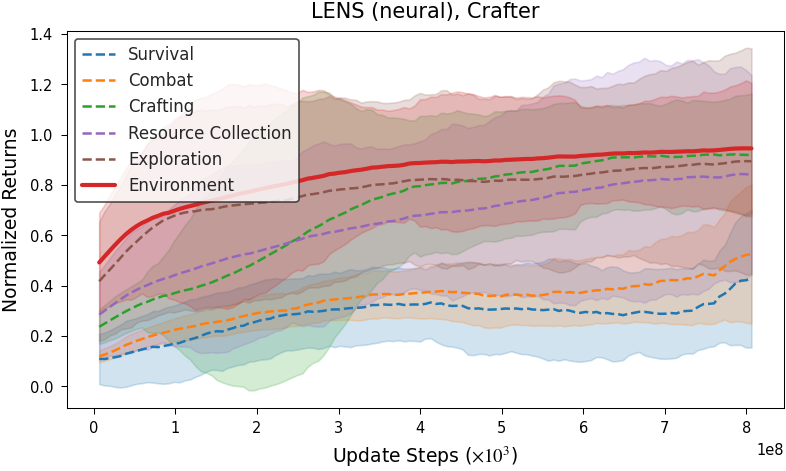

In [11]:
def single_run_plot(ax1, df, run_name, option_labels, game_name):
    # colors = cm.get_cmap("tab10")
    run_name = run_name.lower()
    row = df[df["run_name"] == run_name].iloc[0]

    # sns.set_context("paper")
    sns.set_theme(context="paper", style="ticks")
    # colors = sns.color_palette("colorblind")
    colors = plt.cm.tab10.colors
    # with plt.rc_context({**bundles.neurips2024(usetex=False), **axes.lines()}):
    # fig, ax1 = plt.subplots()
    x_data = row["x_data"]
    eps = 1e-8
    for i, label in enumerate(option_labels):
        # normalize the data
        # option_mean = row[f"opt{i}_ret"].mean(axis=0) / row[f"opt{i}_ret"].mean(axis=0).max()
        stds = np.nanstd(row[f"opt{i}_ret"], axis=0) 
        means = np.nanmean(row[f"opt{i}_ret"], axis=0)
        # rescale
        option_stds = (stds - np.nanmin(stds)) / (np.nanmax(stds) - np.nanmin(stds) + eps)
        option_means = (means - np.nanmin(means)) / (np.nanmax(means) - np.nanmin(means) + eps)
        if game_name == "Crafter":
            option_means = moving_average(option_means, window_size=30)
            option_stds = moving_average(option_stds, window_size=30) 
        x_data = x_data[:len(option_means)]
        color_i = i if i < 3 else i + 1  # we keep red for environment
        ax1.plot(x_data, option_means, label=label, color=colors[color_i], zorder=1, linestyle="--")
        ax1.fill_between(x_data, option_means - option_stds, option_means + option_stds, color=colors[color_i], alpha=0.2, zorder=0)
    # ax1.set_xlabel("Update Steps ($\\times 10^3$)")
    # ax1.set_ylabel("Normalized Skill Returns")

    # Create a second y-axis for the environment reward
    # ax2 = ax1.twinx()
    # env_means = (row["env_ret"] - np.nanmean(row["env_ret"])) / np.nanstd(row["env_ret"])
    means = np.nanmean(row["env_ret"], axis=0)
    stds = np.nanstd(row["env_ret"], axis=0)
    # rescale
    env_means = (means - np.nanmin(means)) / (np.nanmax(means) - np.nanmin(means) + eps)
    env_std = (stds - np.nanmin(stds)) / (np.nanmax(stds) - np.nanmin(stds) + eps)  
    # env_mean = np.nanmean(env_norm, axis=0)
    if game_name == "Crafter":
        env_means = moving_average(env_means, window_size=30)
        env_std = moving_average(env_std, window_size=30)
    x_data = x_data[:len(env_means)]
    ax1.plot(x_data, env_means, label="Environment", color=colors[3], zorder=2, linewidth=2)
    ax1.fill_between(x_data, env_means - env_std, env_means + env_std, color=colors[3], alpha=0.2, zorder=0)
    # remove data from ax2
    # ax2.axhline(max(env_mean), color=colors[i+1], linestyle="--", alpha=1.0, zorder=1)
    # ax2.set_ylabel("Environment Return")
    
    # Combine legends from both axes and ensure they are drawn on top of the lines
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    # lines_2, labels_2 = ax2.get_legend_handles_labels()
    
    # set title
    ax1.set_title(f"{get_algorithm_from_name(run_name)}, {game_name}", fontsize=10)
    # legend = ax1.legend(lines_1 + lines_2, labels_1 + labels_2)#, ncol=2)
    # legend = ax1.legend(lines_2 + lines_1, labels_2 + labels_1)#, ncol=2)
    # legend.set_zorder(3)  # Ensure the legend is drawn on top of the lines
    
    # plt.title("Skill and Environment Returns")
    # plt.tight_layout()
    # plt.savefig(f"{run_name}_skills.pdf", bbox_inches="tight")
    # plt.show()
    return lines_1, labels_1 

with plt.rc_context({**bundles.neurips2024(usetex=False), **axes.lines()}):
    fig, ax1 = plt.subplots()
    handles, labels = single_run_plot(ax1, craftax_df, "pqn_rnn_hier_Craftax-Classic-Symbolic-v1", ["Survival", "Combat", "Crafting", "Resource Collection", "Exploration"], "Crafter")
    plt.legend(handles, labels, loc="upper left", fontsize=8)
    plt.xlabel("Update Steps ($\\times 10^3$)")
    plt.ylabel("Normalized Returns")
    plt.tight_layout()
    plt.savefig("craftax_pqn_hier_llm_Craftax-Classic-Symbolic-v1.pdf", bbox_inches="tight")
    plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


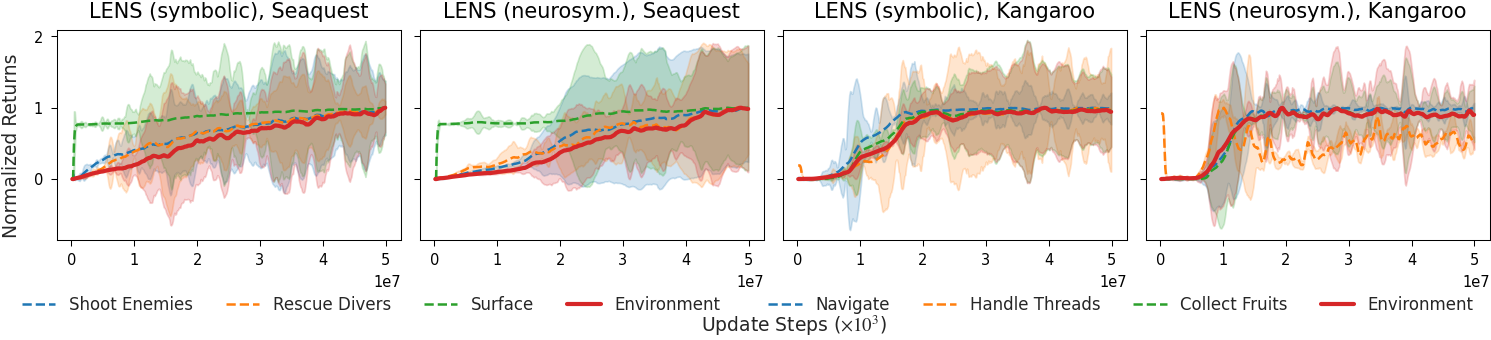

In [12]:

def plot_all_runs():
    with plt.rc_context({**bundles.neurips2024(usetex=False), **axes.lines()}):
        fig, ax = plt.subplots(nrows=1, ncols=4, sharex=True, sharey=True, constrained_layout=True, figsize=(10, 2))

        runs = [
            (seaquest_df, "pqn_hier_llm_Seaquest", ["Shoot Enemies", "Rescue Divers", "Surface"]),
            (seaquest_df, "pqn_hier_comb_Seaquest", ["Shoot Enemies", "Rescue Divers", "Surface"]),
            (kangaroo_df, "pqn_hier_llm_Kangaroo", ["Navigate", "Handle Threads", "Collect Fruits"]),
            (kangaroo_df, "pqn_hier_comb_Kangaroo", ["Navigate", "Handle Threads", "Collect Fruits"]),
        ]
        handles, labels = [], []
        for i, (ax, (df, run_name, labels)) in enumerate(zip(ax.flatten(), runs)):
            name = run_name.split("_")[-1]
            h, l = single_run_plot(ax, df, run_name, labels, name)
            if i % 2 == 0:
                # fig.legend(unique.values(), unique.keys(), bbox_to_anchor=(0.5, -0.03), loc="center", ncol=8, frameon=False, fontsize="small")
                x = 0.25 if i == 0 else 0.75
                fig.legend(h, l, bbox_to_anchor=(x, -0.03), loc="center", ncol=8, frameon=False, fontsize="small")
        # Shared axis labels (only on the figure level)
        config = bundles.neurips2024(usetex=False)#["font"]
        # fig.supxlabel("Update Steps ($\\times 10^3$)", family=config["font.family"], size=config["font.size"])
        fig.supylabel("Normalized Returns", family=config["font.family"], size=config["font.size"])
        # fig.text(1, 0.5, "Environment Return", va="center", rotation=90, family=config["font.family"], size=config["font.size"]) 
        fig.text(0.47, -0.1, "Update Steps ($\\times 10^3$)", va="center", rotation=0, family=config["font.family"], size=config["font.size"]) 

        plt.savefig("skill_returns.pdf", bbox_inches="tight")
        plt.show()
plot_all_runs()
# TODO: two legends, equal y axis limits

/tmp/ipykernel_2636068/4257935128.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following fa

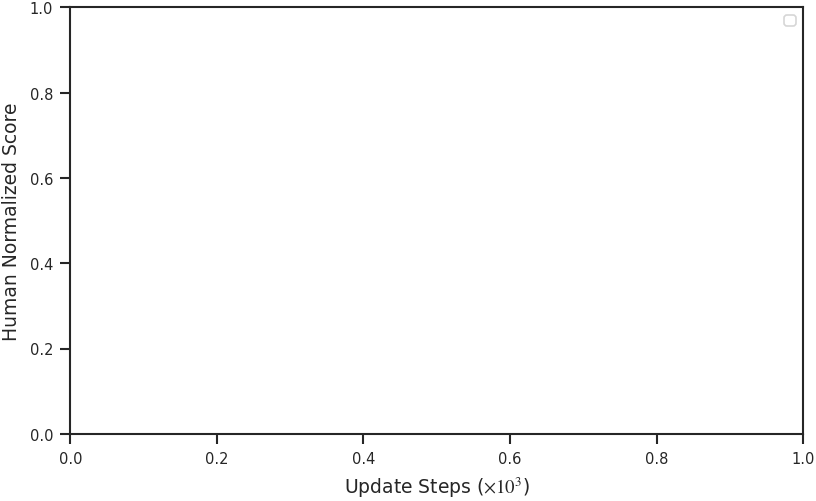

/tmp/ipykernel_2636068/4257935128.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following fa

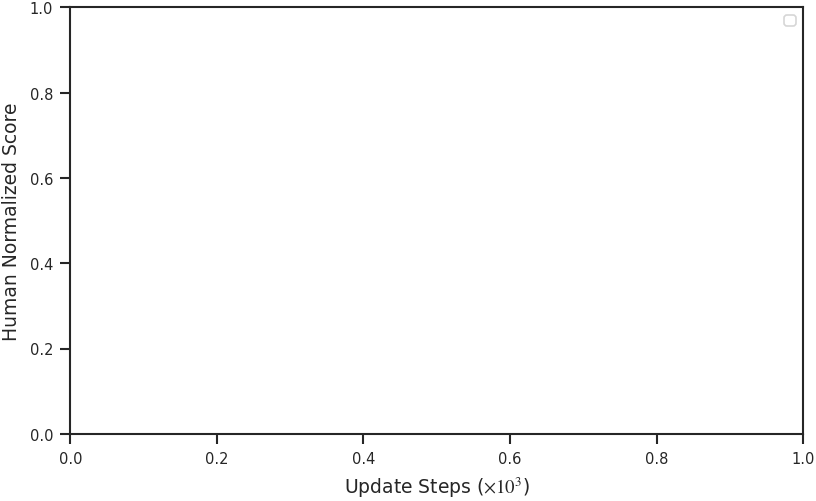

/tmp/ipykernel_2636068/4257935128.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following fa

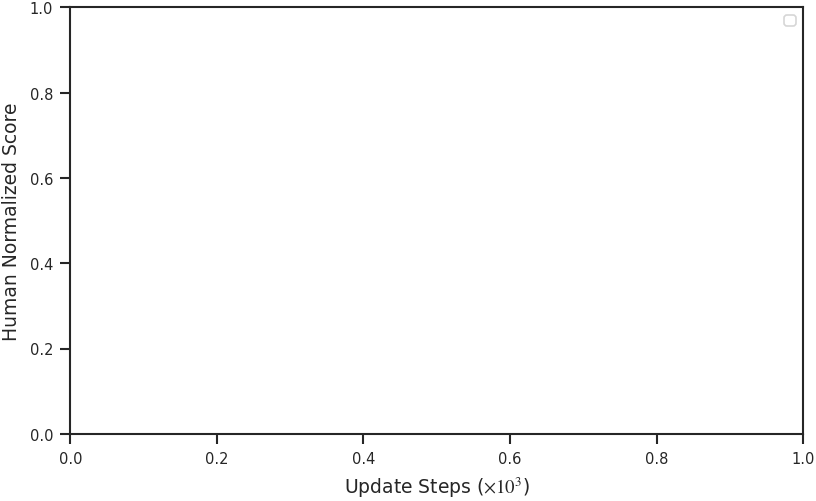

In [13]:
def comparison_plot(df, perf_col, run_names):
    # Set the style
    sns.set_theme(context="paper", style="ticks")
    colors = sns.color_palette("colorblind")
    # Create a figure and axis
    with plt.rc_context(bundles.neurips2024(usetex=False)):
        fig, ax = plt.subplots()
        # Plot the data
        df1 = df[df["run_name"].isin(run_names)]
        for i, row in df1.iterrows():
            # ax.plot(row["env_ret"][0], label=row["algorithm"], color=colors(i), zorder=1)
            # ax.axhline(row["env_ret"][0].max(), color=colors(i), linestyle="--", alpha=0.7, zorder=1)
            # use plt to plot data across multiple seeds
            step = row["x_data"]
            mean = np.mean(row[perf_col], axis=0)
            std = np.std(row[perf_col], axis=0)
            game_name = row["run_name"].split("_")[-1]
            if "Craft" in game_name:
                mean *= (7.9 / 0.0375) # since max test score is 7.9 and max train score is 0.0375 (TODO: check this)
                std *= (7.9 / 0.0375)
            if game_name.lower() in human_random_performance:
                _, human_mean = human_random_performance[game_name.lower()] 
                mean = mean / human_mean
                std = std / human_mean
            # if "Craftax" in run_names[0]:
            #     mean = np.mean(row["test_score"], axis=0)
            #     std = np.std(row["test_score"], axis=0)
            mean = moving_average(mean)
            std = moving_average(std)
            step = step[:len(mean)]
            ax.plot(step, mean, label=row["algorithm"], color=colors[i], zorder=1)
            ax.fill_between(step, mean - std, mean + std, alpha=0.2, color=colors[i], zorder=1)
            ax.axhline(mean.max(), color=colors[i], linestyle="--", alpha=0.7, zorder=1)

        # Set the labels and title
        ax.set_xlabel("Update Steps ($\\times 10^3$)") 
        ax.set_ylabel("Human Normalized Score")
        # if "Craftax" in run_names[0]:
        #     ax.set_ylabel("Test Score")
        # Add a legend
        ax.legend()
        # Show the plot
        # plt.tight_layout()
        name = run_names[0].split("_")[-1]
        plt.savefig(f"{name}_comparison.pdf", bbox_inches="tight")
        plt.show()
comparison_plot(seaquest_df, "env_ret", ["pqn_Seaquest", "pqn_hier_Seaquest", "pqn_hier_llm_Seaquest", "pqn_hier_comb_Seaquest"])
comparison_plot(kangaroo_df, "env_ret", ["pqn_Kangaroo", "pqn_hier_Kangaroo", "pqn_hier_llm_Kangaroo", "pqn_hier_comb_Kangaroo"])
# comparison_plot(craftax_df, ["pqn_Craftax-Classic-Symbolic-v1", "pqn_hier_Craftax-Classic-Symbolic-v1", "pqn_hier_llm_Craftax-Classic-Symbolic-v1", "pqn_hier_llm_comb_Craftax-Classic-Symbolic-v1"])
# comparison_plot(seaquest_df, "env_ret", ["pqn_Seaquest", "pqn_hier_llm_Seaquest", "pqn_hier_comb_Seaquest"])
# comparison_plot(kangaroo_df, "env_ret", ["pqn_Kangaroo", "pqn_hier_llm_Kangaroo", "pqn_hier_comb_Kangaroo"])
comparison_plot(craftax_df, "score", ["pqn_Craftax-Classic-Symbolic-v1", "pqn_hier_Craftax-Classic-Symbolic-v1", "pqn_hier_llm_Craftax-Classic-Symbolic-v1", "pqn_hier_llm_comb_Craftax-Classic-Symbolic-v1"])

In [14]:
kangaroo_df

,run_id,run_name,seeds,algorithm,x_data,env_ret,test_env_ret,modif_test_env_ret,opt0_ret,test_opt0_ret,...,modif_test_opt2_ret,opt3_ret,test_opt3_ret,modif_test_opt3_ret,opt4_ret,test_opt4_ret,modif_test_opt4_ret,opt5_ret,test_opt5_ret,modif_test_opt5_ret
0,356qhfba,ppo_kangaroo,"[rng4146024105, rng928981903]",Unknown,"[131072.0, 409600.0, 442368.0, 540672.0, 68812...","[[14.593505859375, 269.378662109375, 298.67553...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[8.704462051391602, 116.96371459960938, 123.3...","[[-41.400020599365234, -41.400020599365234, -4...",...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.23272705078125, 2.59539794921875, 2.713439...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.04400634765625, 0.6292724609375, 0.5981445...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.10015869140625, 2.38751220703125, 2.542785...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1,ihox8vve,pqn_kangaroo,"[rng1797259609, rng4146024105, rng928981903]",PQN (baseline),"[131072.0, 262144.0, 393216.0, 524288.0, 65536...","[[0.0, 0.0, 0.0, 0.4058837890625, 1.8997192382...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.00790101196616888, 0.07573875784...","[[-17.400001525878906, -17.400001525878906, -1...",...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0013427734375, 0.0073165893...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
2,gilxhnmv,pqn_hier_baseline_kangaroo,"[rng1797259609, rng4146024105, rng928981903]",HPQN (baseline),"[131072.0, 262144.0, 393216.0, 524288.0, 65536...","[[0.0, 0.0, 0.0, 0.07476806640625, 1.454162597...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.07476806640625, 1.454162597...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.00058746337890625, 0.0...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.00037384033203125, 0.006126...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.00042724609375, 0...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
3,s8xlm72j,pqn_hier_kangaroo,"[rng1797259609, rng928981903, rng4146024105]",LENS (neural),"[131072.0, 262144.0, 393216.0, 524288.0, 65536...","[[0.0, 0.0, 0.0, 0.048828125, 1.64794921875, 3...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.024978652596473694, 0.2446527928...","[[-17.400001525878906, -17.400001525878906, -1...",...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.00028228759765625, 0.0...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.000244140625, 0.00576782226...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
4,j9v9fq8b,pqn_hier_llm_kangaroo,"[rng1797259609, rng928981

In [15]:
# What about distribution shifts? How do they handle them?

def extract_performance(df, performance_col, games, algos, normalized_by_pqn=True):
    # in the end, i want (n_algos, n_envs*2) matrix with best performance (and std)
    data = []
    data_std = []
    for algo in algos:
        algo_data = []
        algo_data_std = []
        for game in games:
            # get the run with the maximum environment performance
            new_algo = algo
            if algo == "pqn_hier_comb_pre" and game == "Seaquest":
                new_algo = "pqn_hier_comb_pre_long"
            non_mod = df[df["run_name"] == f"{new_algo}_{game}"][f"{performance_col}"].iloc[0]
            # replace nans with median
            non_mod = np.nan_to_num(non_mod, nan=np.nanmedian(non_mod))
            max_idx = np.nanmean(non_mod, axis=0).argmax() # (1,)

            mod = df[df["run_name"] == f"{new_algo}_{game}"][f"modif_{performance_col}"].iloc[0]
            mod = np.nan_to_num(mod, nan=np.nanmedian(mod))
            if normalized_by_pqn:
                pqn_data = df[df["run_name"] == f"pqn_{game}"][f"{performance_col}"].iloc[0]
                max_pqn = np.nanmean(pqn_data, axis=0).max() + 1e-8  # (1,)
                non_mod = (non_mod - max_pqn) / max_pqn
                mod = (mod-max_pqn) / max_pqn
            algo_data.append(np.nanmean(non_mod, axis=0)[max_idx])
            algo_data.append(np.nanmean(mod, axis=0)[max_idx])
            algo_data_std.append(np.nanstd(non_mod, axis=0)[max_idx])
            algo_data_std.append(np.nanstd(mod, axis=0)[max_idx])
        data.append(algo_data)
        data_std.append(algo_data_std)
    data = np.array(data)
    data_std = np.array(data_std)
    return data.T, data_std.T


def distribution_shift_plot(data, data_std, games, algos,x_axis='algos'):
    sns.set_theme(context="paper", style="ticks")
    # colors = sns.color_palette("colorblind")
    colors = plt.cm.tab20.colors
    with plt.rc_context(bundles.neurips2024(usetex=False)):
        fig, ax = plt.subplots()
        if x_axis == 'games':
            x = np.arange(len(games))
        else:
            x = np.arange(len(algos))
        # x = np.arange(len(algos))  # label locations
        width = 0.2
        if x_axis == 'games':
            ys = algos
        else:
            ys = games
        for i, y in enumerate(ys):
            # get the data for the game
            y_data = data[i]
            y_std = data_std[i]
            # game = games[i] if x_axis != 'games' else games[i%len(games)]
            # base_game = lambda g: g.split("_")[0]
            # human_score = human_performance[base_game(games[i])] if x_axis == 'algos' else [human_performance[base_game(g)] for g in games]
            # y_data = y_data / human_score
            # y_std = y_std / human_score
            # plot the data
            ax.bar(x + i * width, y_data, width, label=y, yerr=y_std, color=colors[i])

        ax.set_ylabel("Performance change")
        ax.set_xticks(x + width*1.5)
        ax.legend()
        xlabel = "Games" if x_axis == 'games' else "Algorithms"
        ax.set_xlabel(xlabel)
        algo_names = [get_algorithm_from_name(algo) for algo in algos]
        ax.set_xticklabels(games if x_axis == 'games' else algo_names)
        ax.set_title("Distribution Shift Performance")
        plt.tight_layout()
        plt.savefig("distribution_shift.pdf", bbox_inches="tight")
        plt.show()

seaquest_df["game"] = "Seaquest"
kangaroo_df["game"] = "Kangaroo"
both_df = pd.concat([seaquest_df, kangaroo_df], ignore_index=True)
# data, data_std = extract_performance(both_df, "test_env_ret", ["Seaquest", "Kangaroo"], ["pqn", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb","pqn_hier_comb_pre"])
# print(data)
# shape of data is (n_envs, n_algos)
# For x-axis=games:
# data = data.T
# data_std = data_std.T
# distribution_shift_plot(data, data_std, ["Seaquest", "Seaquest_mod", "Kangaroo", "Kangaroo_mod"], ["pqn", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb","pqn_hier_comb_pre"], x_axis="algos")


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


label:  seaquest
label:  seaquest_mod
label:  kangaroo
label:  kangaroo_mod


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


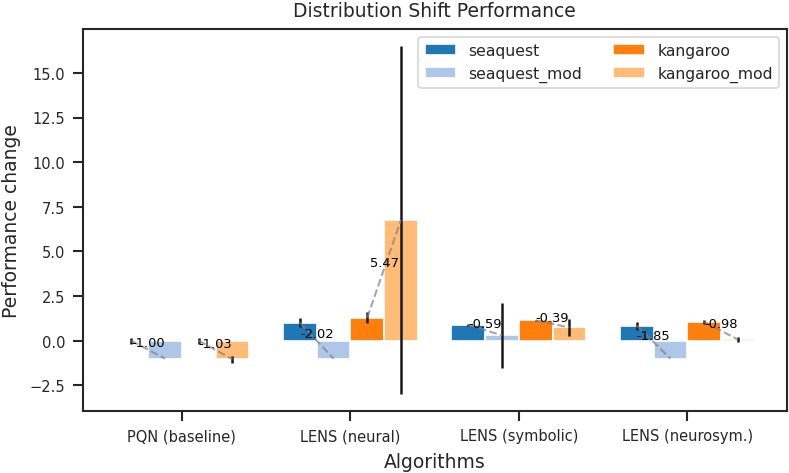

In [16]:
def distribution_shift_plot2(data, data_std, games, algos, x_axis='algos'):
    sns.set_theme(context="paper", style="ticks")
    colors = plt.cm.tab20.colors

    # Helper to normalize raw scores by human baseline
    # def normalize_by_human(raw):
    #     base_game = lambda g: g.split("_")[0]
    #     human_scores = [human_performance[base_game(g)] for g in games]
    #     return raw / np.array(human_scores)[:, None]

    # norm_data = normalize_by_human(data)
    # norm_std  = normalize_by_human(data_std)

    with plt.rc_context(bundles.neurips2024(usetex=False)):
        fig, ax = plt.subplots()
        # positions for each algorithm (or game)
        x = np.arange(len(algos)) if x_axis == 'algos' else np.arange(len(games))
        width = 0.2

        # draw bars
        for i, game in enumerate(games):
            print("label: ", game)
            ax.bar(
                x + i * width,
                data[i],
                width,
                label=game,
                yerr=data_std[i],
                color=colors[i]
            )

        # connection lines + annotations
        pairs = [("seaquest", "seaquest_mod"), ("kangaroo", "kangaroo_mod")]
        idx = {g: i for i, g in enumerate(games)}

        for algo_idx in range(len(algos)):
            for orig, mod in pairs:
                i0, i1 = idx[orig], idx[mod]
                # bar centers
                x0 = x[algo_idx] + i0 * width
                x1 = x[algo_idx] + i1 * width
                # heights
                y0 = data[i0, algo_idx]
                y1 = data[i1, algo_idx]
                # draw dashed connector
                ax.plot([x0, x1], [y0, y1],
                        linestyle='--', linewidth=1,
                        color='gray', alpha=0.7)
                # compute and annotate change (mod - orig)
                delta = y1 - y0
                xm, ym = (x0 + x1) / 2, (y0 + y1) / 2
                ax.text(xm, ym + 0.01,  # offset label slightly above line
                        f"{delta:.2f}",
                        ha='center', va='bottom',
                        fontsize='x-small', color='black')

        # labels, ticks, legend
        ax.set_ylabel("Performance change")
        ax.set_xlabel("Algorithms" if x_axis == 'algos' else "Games")
        ax.set_xticks(x + width * (len(games) - 1) / 2)
        algo_names = [get_algorithm_from_name(a) for a in algos]
        ax.set_xticklabels(algo_names if x_axis == 'algos' else games)
        ax.set_title("Distribution Shift Performance")
        ax.legend(ncol=2, fontsize='small')
        plt.tight_layout()
        plt.savefig("distribution_shift_with_deltas.pdf", bbox_inches="tight")
        plt.show()

data_kang, data_std_kang = extract_performance(kangaroo_df, "test_opt0_ret", ["kangaroo"], ["pqn", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb"])
#(n_envs, n_algos)
#(2, 3)

data_sea, data_std_sea = extract_performance(seaquest_df, "test_env_ret", ["seaquest"], ["pqn", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb"])
#(n_envs, n_algos)
#(2, 3)
data = np.concatenate([data_sea, data_kang], axis=0)
data_std = np.concatenate([data_std_sea, data_std_kang], axis=0)
# print(data.shape, data_std.shape)
distribution_shift_plot2(data, data_std, ["seaquest", "seaquest_mod", "kangaroo", "kangaroo_mod"], ["pqn", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb"], x_axis="algos")

pqn_hier_seaquest
0
pqn_hier_llm_seaquest
1
pqn_hier_comb_seaquest
2
pqn_hier_seaquest
0
pqn_hier_llm_seaquest
1
pqn_hier_comb_seaquest
2
pqn_hier_seaquest
0
pqn_hier_llm_seaquest
1
pqn_hier_comb_seaquest
2
pqn_hier_kangaroo
0
pqn_hier_llm_kangaroo
1
pqn_hier_comb_kangaroo
2
pqn_hier_kangaroo
0
pqn_hier_llm_kangaroo
1
pqn_hier_comb_kangaroo
2
pqn_hier_kangaroo
0
pqn_hier_llm_kangaroo
1
pqn_hier_comb_kangaroo
2


/tmp/ipykernel_2636068/2154827516.py:88: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


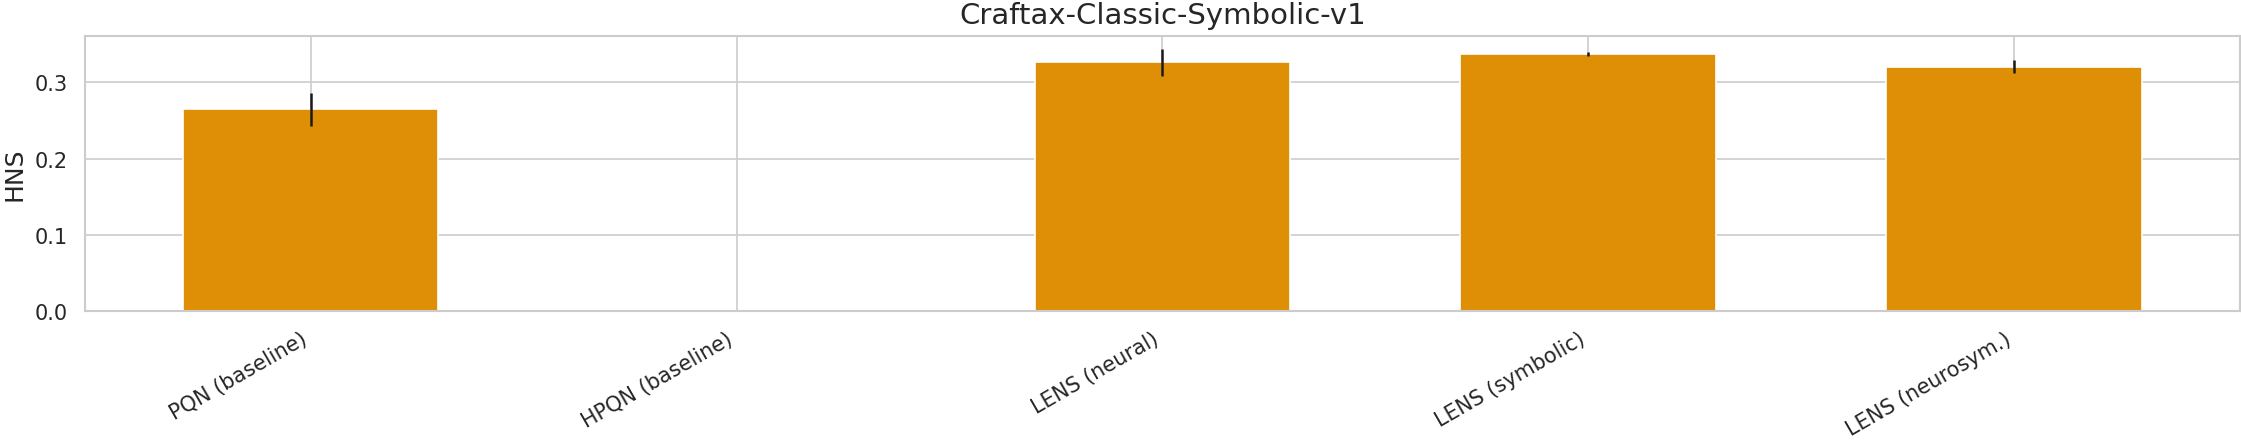

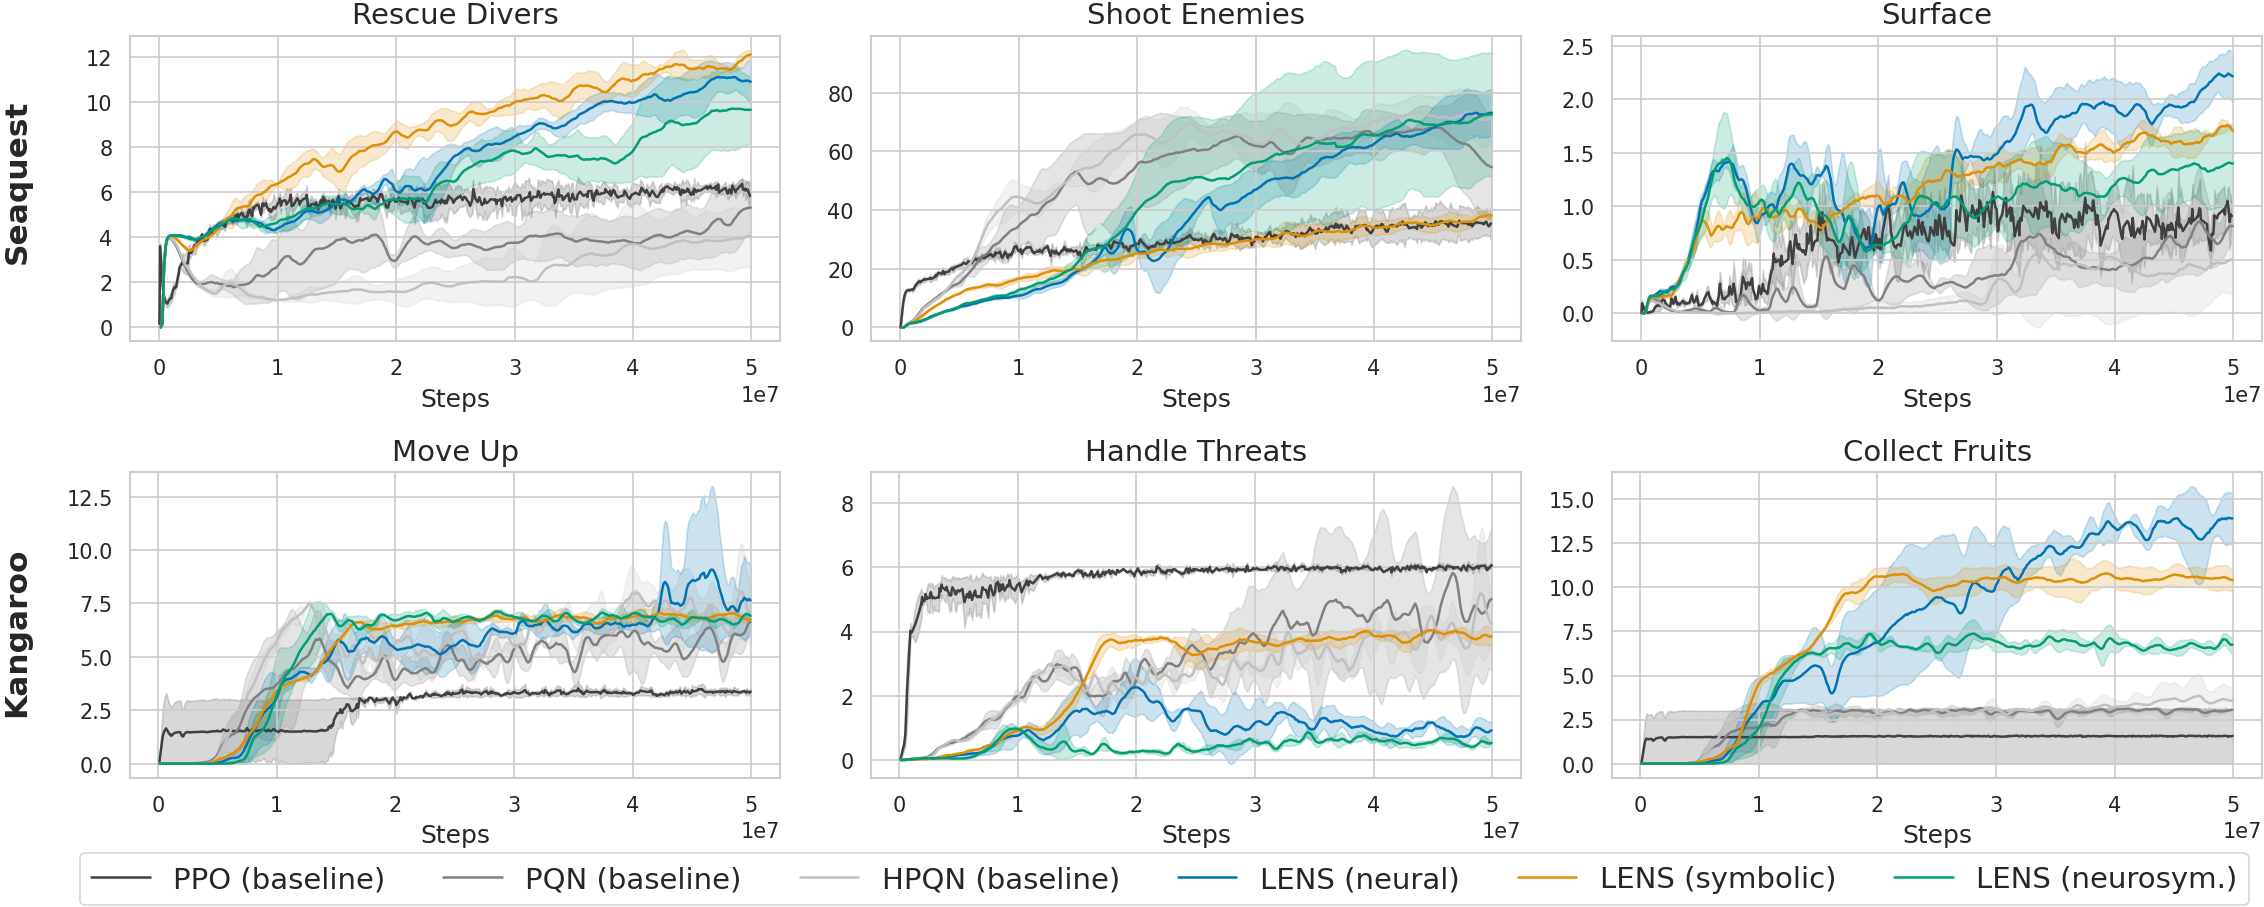

pqn_rnn_hier_craftax-classic-symbolic-v1
0
pqn_rnn_hier_llm_craftax-classic-symbolic-v1
1
pqn_rnn_hier_comb_craftax-classic-symbolic-v1
2
pqn_rnn_hier_craftax-classic-symbolic-v1
0
pqn_rnn_hier_llm_craftax-classic-symbolic-v1
1
pqn_rnn_hier_comb_craftax-classic-symbolic-v1
2
pqn_rnn_hier_craftax-classic-symbolic-v1
0
pqn_rnn_hier_llm_craftax-classic-symbolic-v1
1
pqn_rnn_hier_comb_craftax-classic-symbolic-v1
2
pqn_rnn_hier_craftax-classic-symbolic-v1
0
pqn_rnn_hier_llm_craftax-classic-symbolic-v1
1
pqn_rnn_hier_comb_craftax-classic-symbolic-v1
2
pqn_rnn_hier_craftax-classic-symbolic-v1
0
pqn_rnn_hier_llm_craftax-classic-symbolic-v1
1
pqn_rnn_hier_comb_craftax-classic-symbolic-v1
2


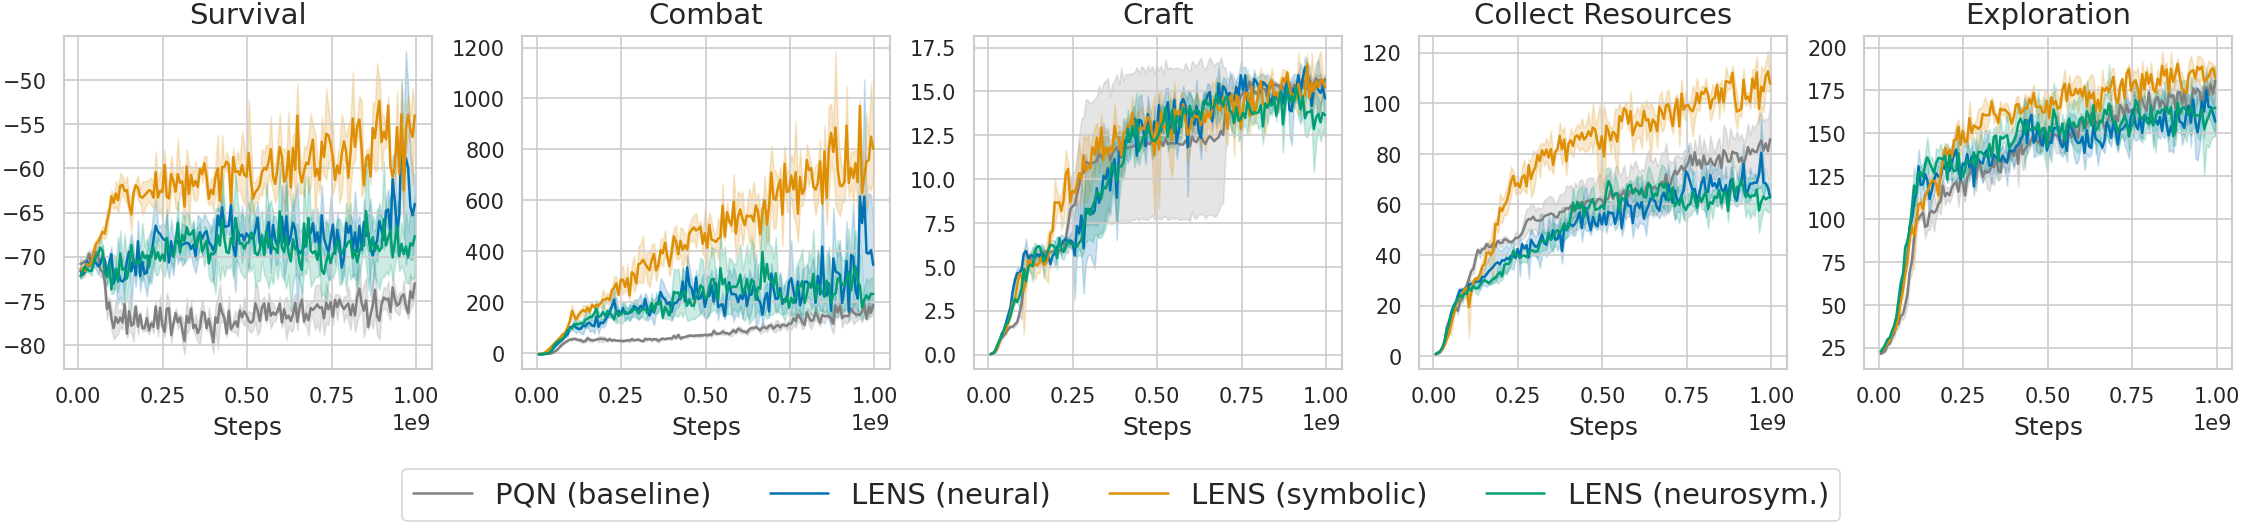

pqn_hier_pong
0
pqn_hier_llm_pong
1
pqn_hier_comb_pong
2
pqn_hier_pong
0
pqn_hier_llm_pong
1
pqn_hier_comb_pong
2
pqn_hier_pong
0
pqn_hier_llm_pong
1
pqn_hier_comb_pong
2
pqn_hier_breakout
0
pqn_hier_llm_breakout
1
pqn_hier_comb_breakout
2
pqn_hier_breakout
0
pqn_hier_llm_breakout
1
pqn_hier_comb_breakout
2
pqn_hier_breakout
0
pqn_hier_llm_breakout
1
pqn_hier_comb_breakout
2
pqn_hier_freeway
0
pqn_hier_llm_freeway
1
pqn_hier_comb_freeway
2
pqn_hier_freeway
0
pqn_hier_llm_freeway
1
pqn_hier_comb_freeway
2


/tmp/ipykernel_2636068/2154827516.py:136: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


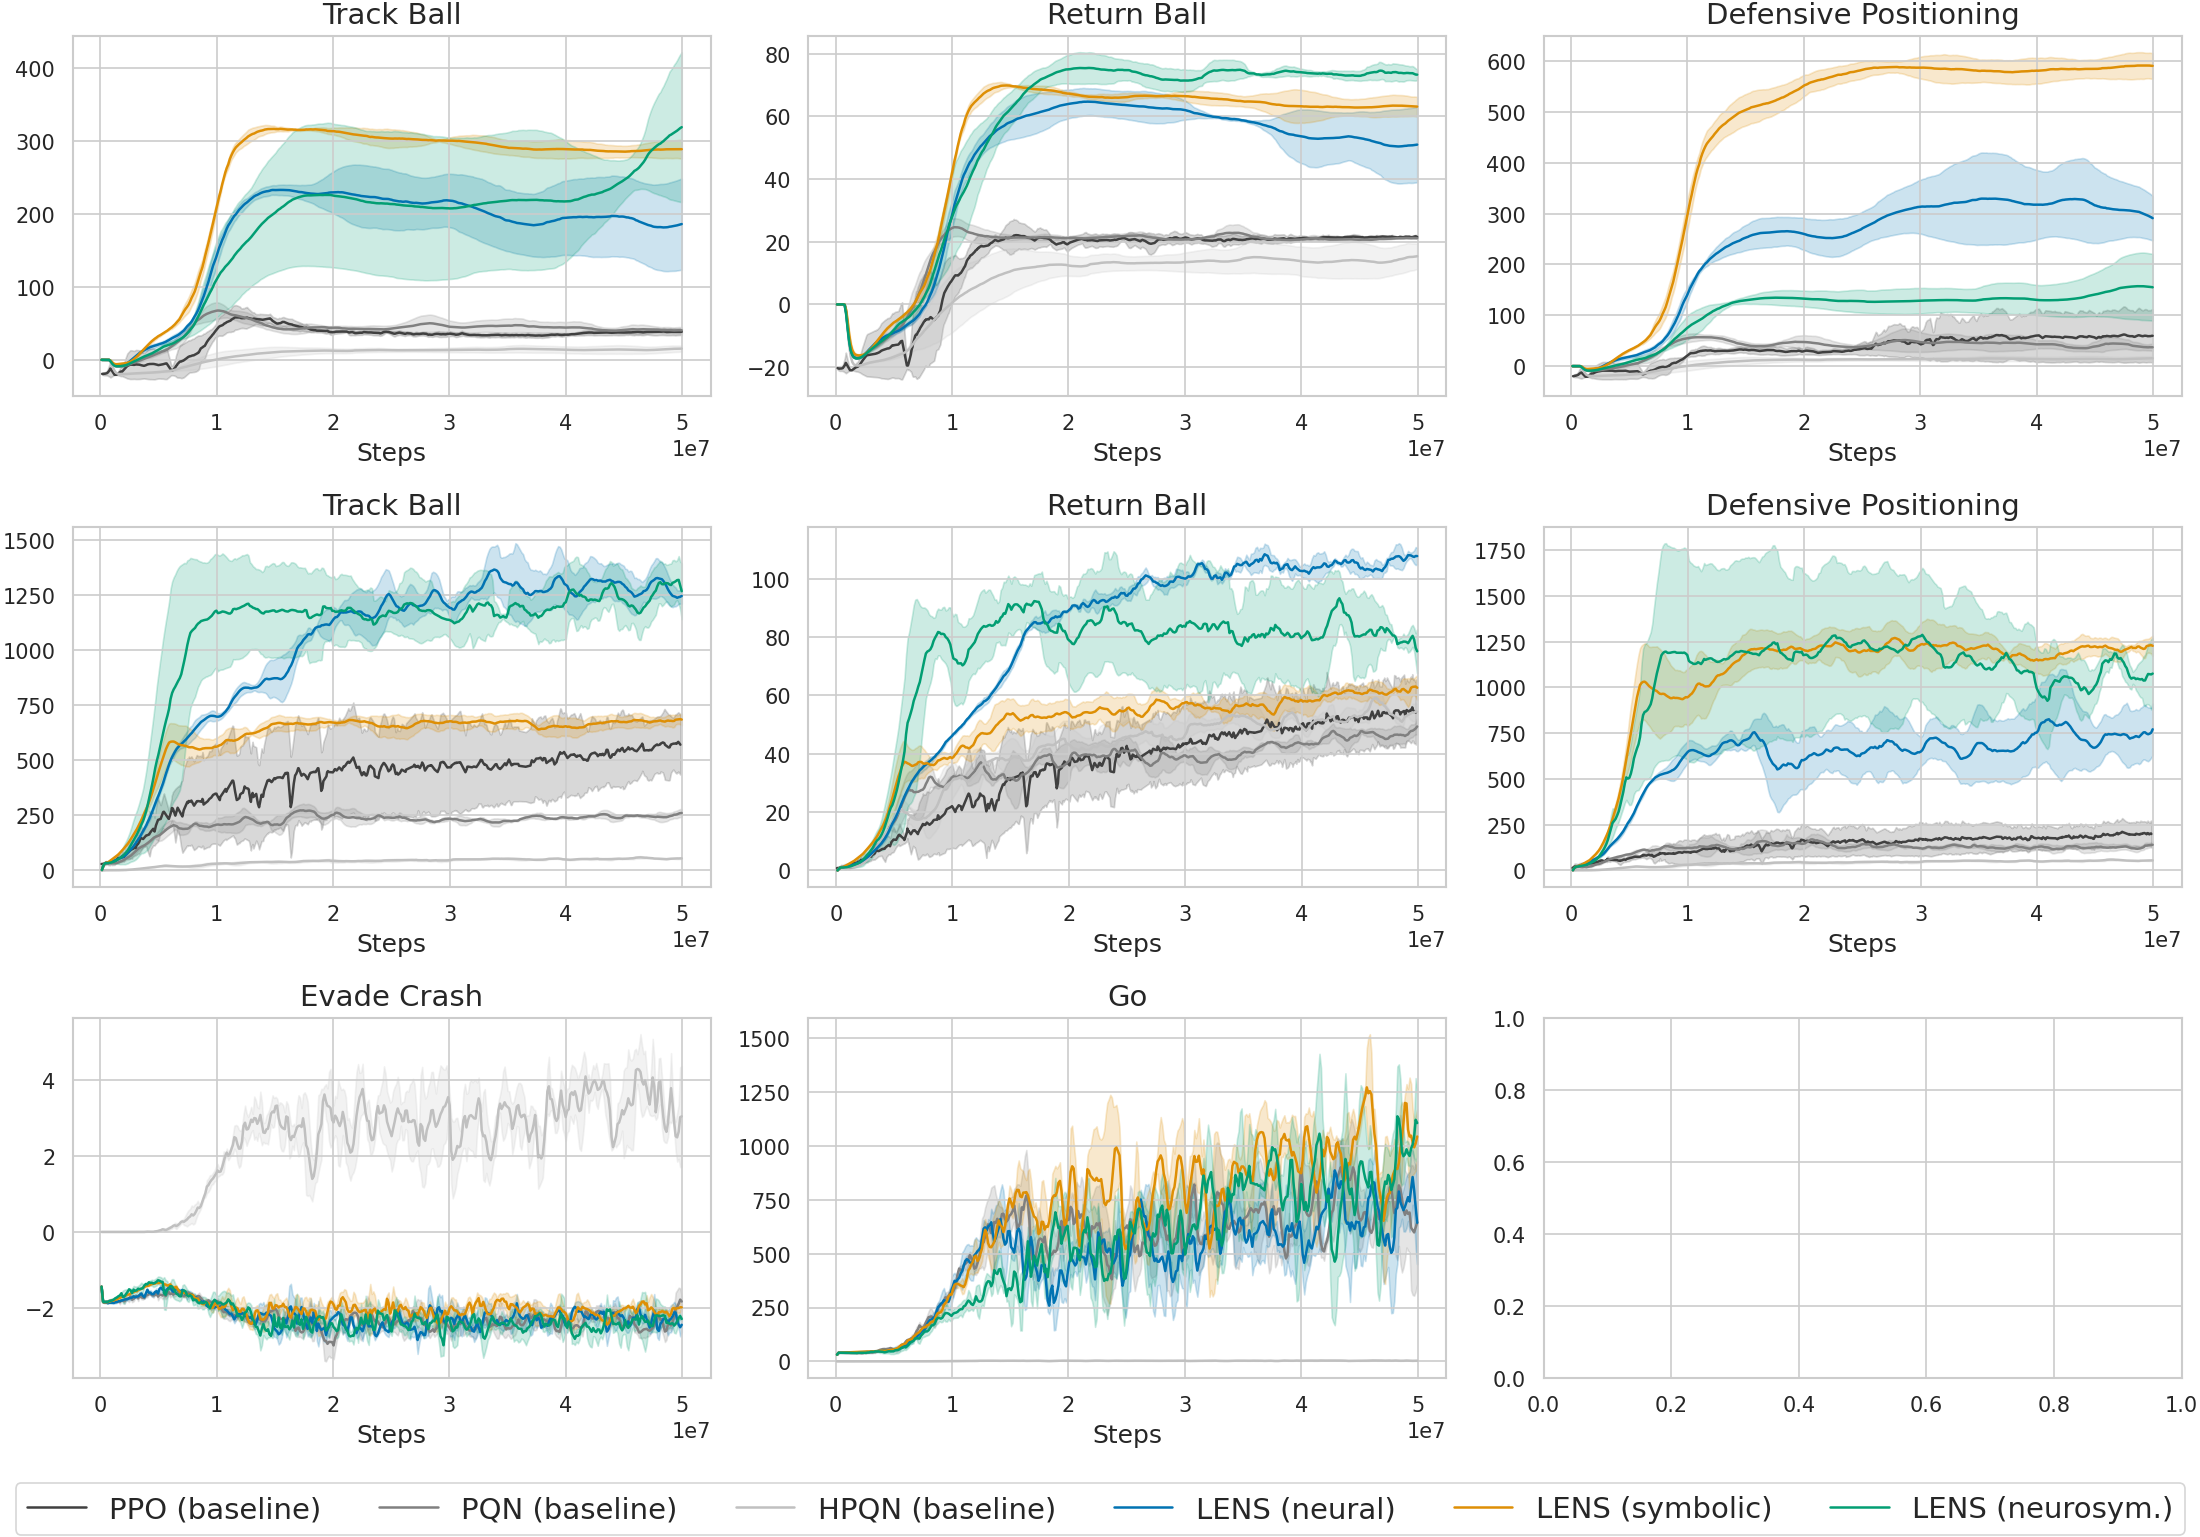

In [26]:

def single_reward_plot(game_data, algos, reward_row, ax, opt_name):
    # plot the reward (e.g. collect_divers) of all algos
    # sns.set_theme(context="paper", style="ticks")
    colors = sns.color_palette("colorblind")
    # gray_palette = ["#d9d9d9", "#bdbdbd", "#969696"]  # light to dark grays
    # gray_palette = ["#969696", "#737373", "#525252"]  # progressively darker
    baselines = ['PPO (baseline)', 'PQN (baseline)', 'HPQN (baseline)']
    non_baselines = [algo for algo in algos if get_algorithm_from_name(algo) not in baselines]
    # colors = sns.color_palette("crest", n_colors=len(non_baselines))  # use a color palette for non-baselines
    colors_baseline = sns.color_palette("gray", n_colors=len(baselines))  # use a gray palette for baselines
    # with plt.rc_context(bundles.neurips2024(usetex=False)):
        # fig, ax = plt.subplots()
    for algo in algos:
        alg = algo
        # if "pqn_hier_comb" in algo and game_data["run_name"].str.contains("Craft").any():
        #     alg = "pqn_hier_llm_comb_Craftax-Classic-Symbolic-v1"
        row = game_data[game_data["run_name"] == alg].iloc[0]
        x_data = row["x_data"]
        means = np.nanmean(row[f"{reward_row}_ret"], axis=0)
        stds = np.nanstd(row[f"{reward_row}_ret"], axis=0)
        # rescale
        # means = (means - np.nanmin(means)) / (np.nanmax(means) - np.nanmin(means) + 1e-8)
        # stds = (stds - np.nanmin(stds)) / (np.nanmax(stds) - np.nanmin(stds) + 1e-8)
        x_data = x_data[:len(means)]
        alg_label = get_algorithm_from_name(algo)
        if alg_label in baselines:
            # make gray
            color = colors_baseline[baselines.index(alg_label)]
        else:
            print(alg)
            print(non_baselines.index(alg))
            color = colors[non_baselines.index(alg)]
            # alg_label = alg_label + " (ours)"
        ax.plot(x_data, means, label=alg_label, color=color, zorder=1)
        ax.fill_between(x_data, means - stds, means + stds, color=color, alpha=0.2, zorder=0)
        ax.set_title(f"{opt_name}")
    # ax.set_ylabel(f"{opt_name} Reward")
    ax.set_xlabel("Steps")
    # ax.legend()

def multi_reward_plot(df, opt_names, axes):
    # plot all single_reward_plots for all envs
    game_name = df["run_name"].iloc[0].split("_")[-1]
    # opts = ["opt0", "opt1", "opt2"]
    opts = ["opt3", "opt4", "opt5"]
    if "sea" in game_name:
        opts = ["opt4", "opt5", "opt6"]
    if "craft" in game_name:
        opts = ["opt0", "opt1", "opt2", "opt3", "opt4"]
    if "freeway" in game_name:
        opts = ["opt0", "opt1"]
    if "breakout" in game_name:
        opts = ["opt0", "opt1", "opt2"]
    if "pong" in game_name:
        opts = ["opt0", "opt1", "opt2"]
    for i, opt in enumerate(opts):
        if "craft" in game_name:
            # single_reward_plot(df, [f"pqn_rnn_{game_name}", f"pqn_rnn_hier_baseline_{game_name}", f"pqn_rnn_hier_{game_name}", f"pqn_rnn_hier_llm_{game_name}", f"pqn_rnn_hier_comb_{game_name}"], opt, axes[i], opt_names[i])
            single_reward_plot(df, [f"pqn_rnn_{game_name}", f"pqn_rnn_hier_{game_name}", f"pqn_rnn_hier_llm_{game_name}", f"pqn_rnn_hier_comb_{game_name}"], opt, axes[i], opt_names[i])
        elif "freeway" in game_name:
            single_reward_plot(df, [f"pqn_{game_name}", f"pqn_hier_baseline_{game_name}", f"pqn_hier_{game_name}", f"pqn_hier_llm_{game_name}", f"pqn_hier_comb_{game_name}"], opt, axes[i], opt_names[i])
        else:
            single_reward_plot(df, [f"ppo_{game_name}", f"pqn_{game_name}", f"pqn_hier_baseline_{game_name}", f"pqn_hier_{game_name}", f"pqn_hier_llm_{game_name}", f"pqn_hier_comb_{game_name}"], opt, axes[i], opt_names[i])

with plt.rc_context({
    **bundles.neurips2024(usetex=False),
    # **axes.lines(),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 14,
    "font.size": 12
}):
    sns.set_style("whitegrid")
    fig, axs = plt.subplots(2, 3, figsize=(15, 6))
    seaquest_opt_names = ["Rescue Divers", "Shoot Enemies", "Surface"]
    kangaroo_opt_names = ["Move Up", "Handle Threats", "Collect Fruits"]
    multi_reward_plot(seaquest_df, seaquest_opt_names, axs[0])
    multi_reward_plot(kangaroo_df, kangaroo_opt_names, axs[1]) 

    # Create shared legend
    handles, labels = axs[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(labels), bbox_to_anchor=(0.5, -0.05))

    fig.text(-0.01, 0.77, "Seaquest", va='center', ha='center', rotation='vertical', fontsize=15, fontweight='bold')
    fig.text(-0.01, 0.27, "Kangaroo", va='center', ha='center', rotation='vertical', fontsize=15, fontweight='bold')
    fig.tight_layout()
    fig.savefig("multi_reward_plot_seaquest_kangaroo.pdf", bbox_inches="tight")
    plt.show()

with plt.rc_context({
    **bundles.neurips2024(usetex=False),
    # **axes.lines(),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 14,
    "font.size": 12
}):
    sns.set_style("whitegrid")
    # Craftax as separate plot
    fig, axs = plt.subplots(1, 5, figsize=(15, 3))
    craftax_opt_names = ["Survival", "Combat", "Craft", "Collect Resources", "Exploration"]
    multi_reward_plot(craftax_df, craftax_opt_names, axs)
    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(labels), bbox_to_anchor=(0.5, -0.20))
    plt.savefig("multi_reward_plot_craftax.pdf", bbox_inches="tight")
    plt.show()

with plt.rc_context({
    **bundles.neurips2024(usetex=False),
    # **axes.lines(),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 14,
    "font.size": 12
}):
    sns.set_style("whitegrid")
    # Remaining as separate plot
    breakout_opt_names = ["Track Ball", "Return Ball", "Defensive Positioning"]
    pong_opt_names = ["Track Ball", "Return Ball", "Defensive Positioning"]
    freeway_opt_names = ["Evade Crash", "Go"]
    fig, axs = plt.subplots(3, 3, figsize=(15, 10))
    multi_reward_plot(pong_df, pong_opt_names, axs[0]) 
    multi_reward_plot(breakout_df, breakout_opt_names, axs[1])
    multi_reward_plot(freeway_df, freeway_opt_names, axs[2]) 
    handles, labels = axs[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(labels), bbox_to_anchor=(0.5, -0.05))
    # fig.text(-0.01, 0.77, "Pong", va='center', ha='center', rotation='vertical', fontsize=15, fontweight='bold')
    # fig.text(-0.01, 0.27, "Breakout", va='center', ha='center', rotation='vertical', fontsize=15, fontweight='bold')
    # fig.text(-0.01, -0.23, "Freeway", va='center', ha='center', rotation='vertical', fontsize=15, fontweight='bold')
    fig.tight_layout()
    plt.savefig("multi_reward_plot_rest.pdf", bbox_inches="tight")
    plt.show()


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


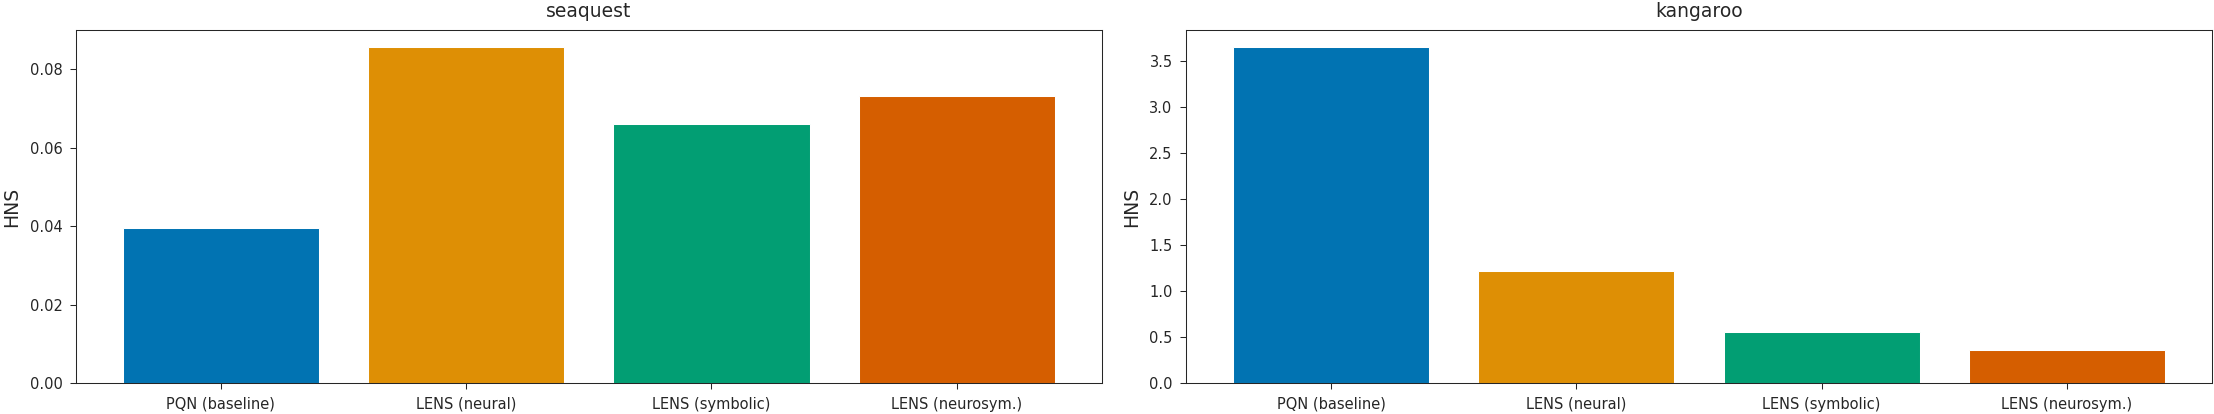

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


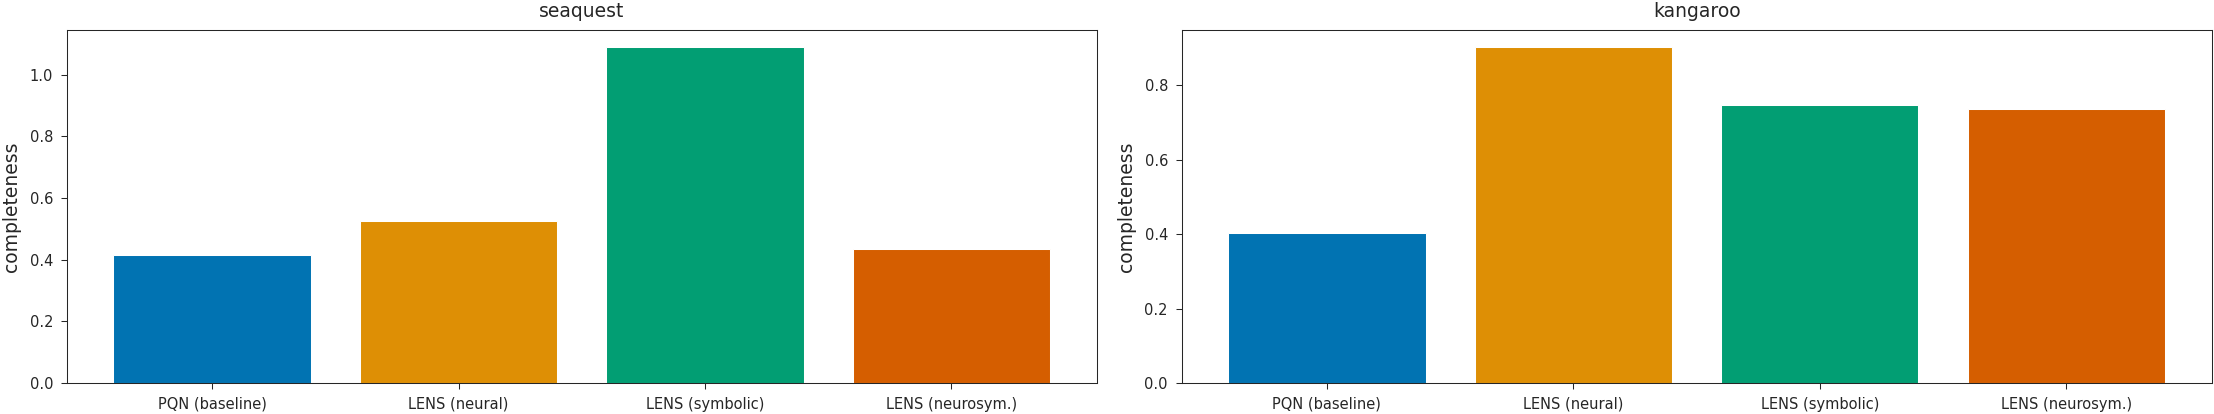

In [27]:
# Comparison bar plot (compare only best scores: human expert normalized env rewards, %of level completed/number divers rescued)
# On games and game-mods (goal is to show that while env rewards might be better for PQN, we are better aligned and can deal with modifications)

# double plots: first: x-axis: Seaquest/Kang, y-axis: HNS, second: y-axis: % of level completed/divers rescued
# One for default games, one for modified games

def single_comparison_plot(df, game_name, algos, metric, ax):
    colors = sns.color_palette("colorblind")
    # bar plot with only highest test_env_ret for each algo
    for i, algo in enumerate(algos):
        row = df[df["run_name"] == f"{algo}_{game_name}"].iloc[0]
        # get the best test_env_ret
        if metric == "HNS":
            y_data = np.nanmax(row["test_env_ret"])
            # normalize by human score
            base_game = lambda g: g.split("_")[0].lower()
            human_score = human_random_performance[base_game(game_name)][1]
            y_data /= human_score
        elif metric == "completeness":
            if game_name == "kangaroo":
                y_data = np.nanmax(row["test_opt0_ret"]) / 432
            elif game_name == "seaquest":
                y_data = (np.nanmax(row["test_opt1_ret"]) + 3) / (np.nanmax(row["test_opt0_ret"]) + 3)
        ax.bar(i, y_data, label=algo, color=colors[i])
        ax.set_xticks(np.arange(len(algos)))
        ax.set_xticklabels([get_algorithm_from_name(a) for a in algos])
        ax.set_ylabel(metric)
        ax.set_title(f"{game_name}")

with plt.rc_context({**bundles.neurips2024(usetex=False), **axes.lines()}):
    # human normalized scores
    # put both seaquest and kangaroo in one figure
    fig, ax = plt.subplots(1, 2, figsize=(15, 3))
    single_comparison_plot(seaquest_df, "seaquest", ["pqn", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb"], "HNS", ax[0])
    single_comparison_plot(kangaroo_df, "kangaroo", ["pqn", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb"], "HNS", ax[1])
    # save the figure
    plt.tight_layout()
    plt.savefig("comparison_hns.pdf", bbox_inches="tight")
    plt.show()

    # % of level completed / number of divers rescued
    # this is hardcoded
    # For kangaroo: reaching the joey (3x) is opt0 == 432
    # For seaquest: opt1 + 3 (due to -1 for dying)
    fig, ax = plt.subplots(1, 2, figsize=(15, 3))
    single_comparison_plot(seaquest_df, "seaquest", ["pqn", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb"], "completeness", ax[0])
    single_comparison_plot(kangaroo_df, "kangaroo", ["pqn", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb"], "completeness", ax[1])
    # save the figure
    plt.tight_layout()
    plt.savefig("comparison_completeness.pdf", bbox_inches="tight")
    plt.show()



In [28]:
def dual_metric_plot(df, game_name, algos, ax, modified=False):
    colors = sns.color_palette("colorblind")
    pastels = sns.color_palette("pastel")
    baselines = ["ppo", "pqn", "pqn_hier_baseline"] 
    bar_colors_hns = []
    bar_colors_comp = []
    for algo in algos:
        if algo in baselines:
            # bar_colors_hns.append("lightgray")  # for HNS bars
            # bar_colors_comp.append("gray")      # for completeness bars
            bar_colors_hns.append(pastels[0])  # for HNS barn
            bar_colors_comp.append(pastels[1])      # for completeness bars
        else:
            bar_colors_hns.append(colors[0])    # method/ablations
            bar_colors_comp.append(colors[1])
    base_game = lambda g: g.split("_")[0].lower()
    random_score, human_score = human_random_performance[base_game(game_name)]

    ax2 = ax.twinx()

    hns_vals, comp_vals = [], []
    hns_modif_vals, comp_modif_vals = [], []
    hns_std, hns_modif_std, comp_std, comp_modif_std = [], [], [], []

    for i, algo in enumerate(algos):
        row = df[df["run_name"] == f"{algo.lower()}_{game_name.lower()}"].iloc[0]
        # HNS
        # find argmax of time step across all seeds (axis=0)
        mean_ret = np.nanmean(row["test_env_ret"], axis=0)
        std_ret = np.nanstd(row["test_env_ret"], axis=0)
        max_hns_idx = mean_ret.argmax()
        hns = (mean_ret[max_hns_idx] - random_score) / (human_score - random_score + 1e-8)
        hns_stds = std_ret[max_hns_idx] / (human_score - random_score + 1e-8)  # normalize by human score

        mean_modif = np.nanmean(row["modif_test_env_ret"], axis=0)
        std_modif = np.nanstd(row["modif_test_env_ret"], axis=0)
        # max_hns_modif_idx = mean_modif.argmax()
        max_hns_modif_idx = max_hns_idx
        hns_modif = (mean_modif[max_hns_modif_idx] - random_score) / (human_score - random_score + 1e-8)
        hns_modif_stds = std_modif[max_hns_modif_idx] / (human_score - random_score + 1e-8)  # normalize by human score
        hns_vals.append(hns)
        hns_modif_vals.append(hns_modif)
        hns_std.append(hns_stds)
        hns_modif_std.append(hns_modif_stds)


        # Completeness or Divers Rescued
        if game_name == "Kangaroo":
            mean_comp = np.nanmean(row["test_opt3_ret"], axis=0)
            std_comp = np.nanstd(row["test_opt3_ret"], axis=0)
            mean_modif_comp = np.nanmean(row["modif_test_opt3_ret"], axis=0)
            std_modif_comp = np.nanstd(row["modif_test_opt3_ret"], axis=0)
            max_comp_idx, max_modif_comp_idx = max_hns_idx , max_hns_idx
            # max_comp_idx = mean_comp.argmax()
            # max_modif_comp_idx = mean_modif_comp.argmax()
            comp = (mean_comp[max_comp_idx]/9)*100 #/3 (for lives), /3 (for 3 platform levels)
            comp_modif = (mean_modif_comp[max_modif_comp_idx]/9)*100
            print(algo, mean_comp[max_comp_idx], mean_modif_comp[max_modif_comp_idx])
            comp_stds = std_comp[max_comp_idx] / 9 *100
            comp_modif_stds = std_modif_comp[max_modif_comp_idx] / 9 *100

            def compute_corrected_std(all_max_comps):
                all_adjusted_comps = []
                for val in all_max_comps:
                    if val / 3 > 3:
                        platforms_level_2 = (val / 3) - 3
                        equiv = (platforms_level_2 / 6) / 3 # /3 for theoretical 3 platforms (of lvl1 equivalent platforms) in lvl2
                        adjusted = 100 + equiv*100 # as prob (not in %)
                        all_adjusted_comps.append(adjusted)
                    else:
                        all_adjusted_comps.append(val/9*100)
                print("all adjusted: ", all_adjusted_comps)
                comp_stds = np.std(all_adjusted_comps)
                return comp_stds

            # Correcting runs where platform is reached and then goes down ladder and back up -> artificially high values
            # Checked game footage for the following game finish percentages
            # checked all seeds (3 runs)
            if algo == "pqn_hier_llm":
                comp = (60+68+67) / 3 #reaches platform 2 in all 3 cases 
                comp_modif = (33+66+66)/3 #reaches platform 2 in 2 cases, else just 1
                comp_stds = np.std([60, 68, 67])
                comp_modif_stds = np.std([33, 66, 66]) 
            else: # all other runs look okay
                # It looks like it would also be the case for comb, but one of the seeds actually reaches level2 !!
                # so more than 100% is possible 
                # problem is that lvl 2 has 6 small platforms before reaching a level1 equivalent
                # so subtract 6, if reaching level 2
                if mean_comp[max_comp_idx] / 3 > 3: # reached lvl2 (/3 for num_lives)
                    platforms_level_2 = (mean_comp[max_comp_idx] / 3) - 3 #everything higher than the 3 lvl1 platforms (3 lives)
                    # divide by 6 to reach level1 equivalent (since 6 platforms in lvl2 equal 1 platform in lvl3)
                    equiv = (platforms_level_2 / 6) / 3 # /3 for theoretical 3 platforms (of lvl1 equivalent platforms) in lvl2
                    # 100 for lvl1 + x% for lvl2
                    comp = 100 + equiv * 100
                    all_max_comps = row["test_opt3_ret"][:, max_comp_idx]
                    comp_stds = compute_corrected_std(all_max_comps)

                if mean_modif_comp[max_modif_comp_idx] / 3 > 3:
                    platforms_level_2 = (mean_modif_comp[max_modif_comp_idx] / 3) - 3
                    # divide by 6 to reach level1 equivalent
                    equiv = (platforms_level_2 / 6) / 3 # /3 for theoretical 3 platforms (of lvl1 equivalent platforms) in lvl2
                    comp_modif = 100 + equiv * 100
                    all_max_modif_comps = row["modif_test_opt3_ret"][:, max_modif_comp_idx]
                    comp_modif_stds = compute_corrected_std(all_max_modif_comps)

        elif game_name == "Seaquest":
            mean_comp = np.nanmean(row["test_opt4_ret"], axis=0)
            std_comp = np.nanstd(row["test_opt4_ret"], axis=0)
            mean_modif_comp = np.nanmean(row["modif_test_opt4_ret"], axis=0)
            std_modif_comp = np.nanstd(row["modif_test_opt4_ret"], axis=0)
            # max_comp_idx = mean_comp.argmax()
            # max_modif_comp_idx = mean_modif_comp.argmax()
            max_comp_idx, max_modif_comp_idx = max_hns_idx , max_hns_idx
            comp = mean_comp[max_comp_idx]
            comp_modif = mean_modif_comp[max_modif_comp_idx]
            comp_stds = std_comp[max_comp_idx]
            comp_modif_stds = std_modif_comp[max_modif_comp_idx]
        comp_vals.append(comp)
        comp_modif_vals.append(comp_modif)
        comp_std.append(comp_stds)
        comp_modif_std.append(comp_modif_stds)

    if modified:
        hns_vals = hns_modif_vals
        comp_vals = comp_modif_vals
        hns_std = hns_modif_std
        comp_std = comp_modif_std
    # Plot HNS
    # ax.bar(np.arange(len(algos)) - 0.2, hns_vals, yerr=hns_std, width=0.4, label="HNS", color=colors[0])
    ax.bar(np.arange(len(algos)) - 0.2, hns_vals, yerr=hns_std, width=0.4, label="HNS", color=bar_colors_hns)
    ax.set_ylabel("HNS", color=colors[0], fontweight='bold')
    ax.tick_params(axis='y', labelcolor=colors[0])

    # Plot Completeness / Divers
    # ax2.bar(np.arange(len(algos)) + 0.2, comp_vals, yerr=comp_std, width=0.4, 
    #         label="% level completed" if game_name == "Kangaroo" else "Divers Rescued", 
    #         color=colors[1])
    ax2.bar(np.arange(len(algos)) + 0.2, comp_vals, yerr=comp_std, width=0.4, 
            label="Level Completion (%)" if game_name == "Kangaroo" else "Divers Rescued", 
            color=bar_colors_comp)
    ax2.set_ylabel("Level Completion (%)" if game_name == "Kangaroo" else "Divers Rescued", color=colors[1], fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=colors[1])
    ax.set_xticks(np.arange(len(algos)))
    ax.set_xticklabels([get_algorithm_from_name(a) for a in algos])#, rotation=30, ha='right')

    import matplotlib.transforms as mtransforms

    labels = ax.get_xticklabels()
    # offset = -5  # negative moves left, positive moves right (in points)
    offset = 15  # negative moves left, positive moves right (in points)
    for label in labels:
        label.set_rotation(30)
        label.set_ha('right')  # or 'center'
        # label.set_transform(label.get_transform() + mtransforms.ScaledTranslation(offset/72, 0, ax.figure.dpi_scale_trans))


    ax.set_ylim(bottom=0)
    ax2.set_ylim(bottom=0)

    ax.set_title(game_name)

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


ppo 3.0000001192092896 3.0
pqn 3.00000007947286 2.0
pqn_hier_baseline 4.666666746139526 3.0
pqn_hier 6.0 3.6666666666666665
pqn_hier_llm 6.853444576263428 8.797731717427572
pqn_hier_comb 6.333333810170491 3.0


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


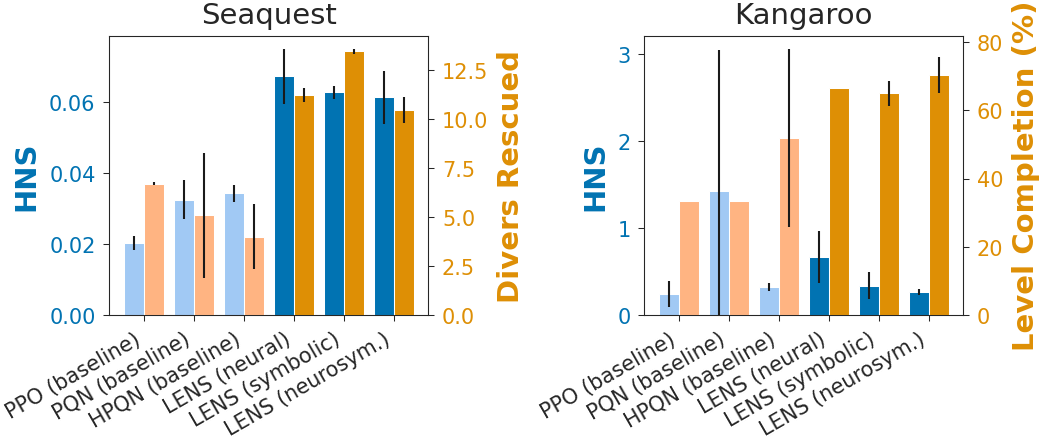

In [29]:
# non modified
with plt.rc_context({
    **bundles.neurips2024(usetex=False),
    **axes.lines(),
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.size": 12
}):
    # fig, ax = plt.subplots(1, 2, figsize=(15, 3))
    fig, ax = plt.subplots(1, 2, figsize=(7, 3))
    dual_metric_plot(seaquest_df, "Seaquest", ["ppo", "pqn","pqn_hier_baseline", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb"], ax[0])
    dual_metric_plot(kangaroo_df, "Kangaroo", ["ppo", "pqn", "pqn_hier_baseline", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb"], ax[1])
    # plt.tight_layout()
    plt.savefig("comparison_dual_metric.pdf", bbox_inches="tight")
    plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


ppo 3.0000001192092896 3.0
pqn 3.00000007947286 2.0
pqn_hier_baseline 4.666666746139526 3.0
pqn_hier 6.0 3.6666666666666665
pqn_hier_llm 6.853444576263428 8.797731717427572
pqn_hier_comb 6.333333810170491 3.0


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


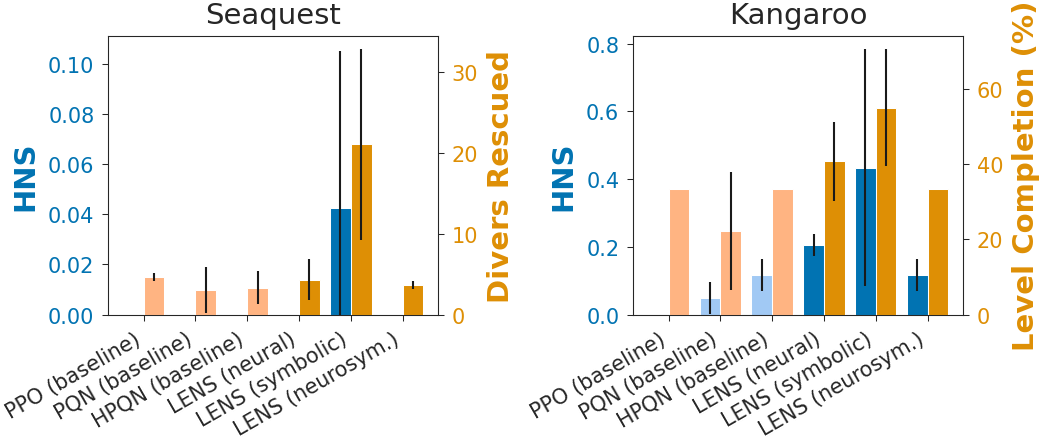

In [30]:
# modified
with plt.rc_context({
    **bundles.neurips2024(usetex=False),
    **axes.lines(),
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.size": 12
}):
    fig, ax = plt.subplots(1, 2, figsize=(7, 3))
    dual_metric_plot(seaquest_df, "Seaquest", ["ppo", "pqn", "pqn_hier_baseline","pqn_hier", "pqn_hier_llm", "pqn_hier_comb"], ax[0], modified=True)
    dual_metric_plot(kangaroo_df, "Kangaroo", ["ppo", "pqn", "pqn_hier_baseline", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb"], ax[1], modified=True)
    # plt.tight_layout()
    plt.savefig("comparison_dual_metric_modif.pdf", bbox_inches="tight")
    plt.show()


In [31]:
# bar plot: final reached performances of skills - both original and modified

In [32]:
def multi_metric_barplot(df, game_name, algos, ax, metric_names, metric_labels):
    """
    Plot multiple metrics as grouped bars per algorithm.

    Args:
        df (pd.DataFrame): DataFrame with algorithm performance.
        game_name (str): Name of the game to extract relevant data.
        algos (list[str]): List of algorithm identifiers.
        ax (matplotlib.axes.Axes): Axes object to plot on.
        metric_names (list[str]): List of 3 column names to plot (e.g., ["test_opt3_ret", ...]).
        metric_labels (list[str]): List of labels to use in the legend (e.g., ["Divers Rescued", ...]).
    """
    assert len(metric_names) == 3 == len(metric_labels), "Expecting exactly 3 metrics to plot."

    colors = sns.color_palette("colorblind")
    bar_width = 0.25
    offsets = [-bar_width, 0, bar_width]
    
    metrics_means = [[] for _ in range(3)]
    metrics_stds = [[] for _ in range(3)]

    for algo in algos:
        row = df[df["run_name"] == f"{algo.lower()}_{game_name.lower()}"].iloc[0]
        for i, metric in enumerate(metric_names):
            vals = np.nanmean(row[metric], axis=0)
            stds = np.nanstd(row[metric], axis=0)
            #TODO: find better way to select best run (maybe argmax of env_reward?)
            best_idx = vals.argmax()
            metrics_means[i].append(vals[best_idx])
            metrics_stds[i].append(stds[best_idx])

    x = np.arange(len(algos))
    for i in range(3):
        ax.bar(x + offsets[i], metrics_means[i], yerr=metrics_stds[i], width=bar_width, label=metric_labels[i], color=colors[i])

    ax.set_xticks(x)
    ax.set_xticklabels([get_algorithm_from_name(a) for a in algos])
    ax.set_ylabel("PQN Normalized Performance")
    ax.set_title(game_name)
    ax.legend()


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


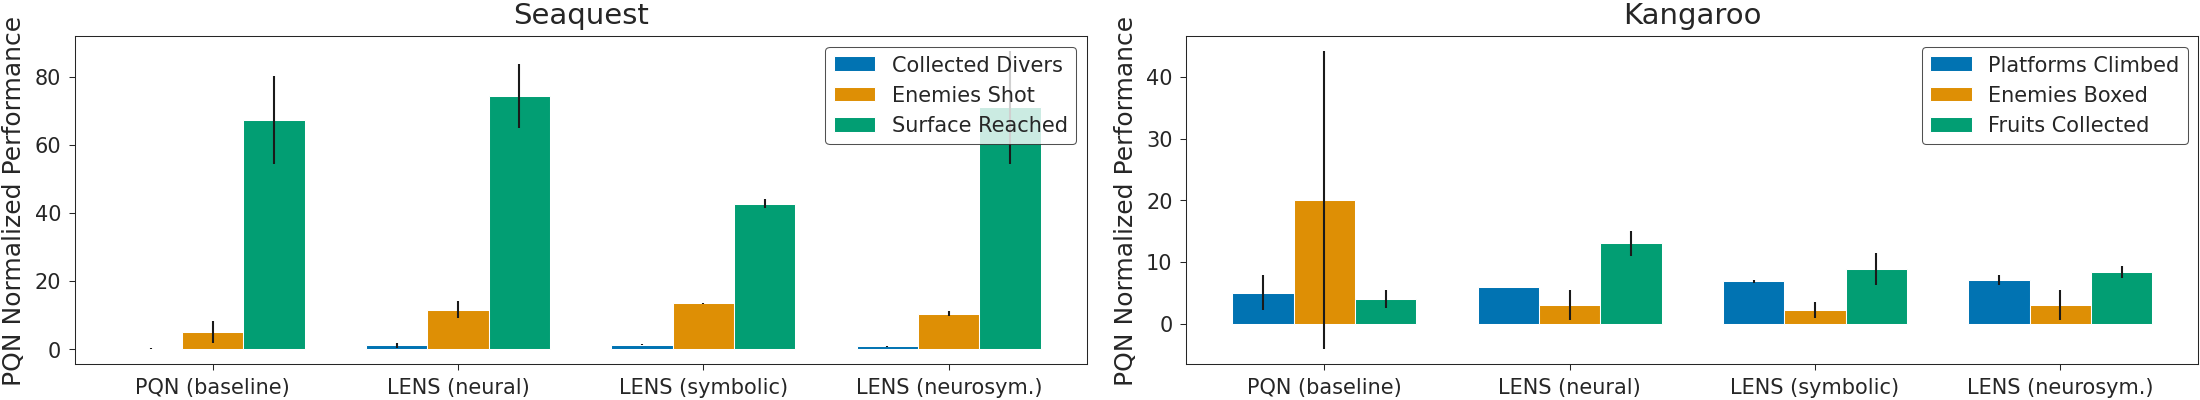

In [33]:
with plt.rc_context({
    **bundles.neurips2024(usetex=False),
    **axes.lines(),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.size": 12
}):
    fig, ax = plt.subplots(1, 2, figsize=(15, 3))
    multi_metric_barplot(seaquest_df, "Seaquest", ["pqn", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb"], ax[0],
                     ["test_opt3_ret", "test_opt4_ret", "test_opt5_ret"], ["Collected Divers", "Enemies Shot", "Surface Reached"])
    multi_metric_barplot(kangaroo_df, "Kangaroo", ["pqn", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb"], ax[1],
                     ["test_opt3_ret", "test_opt4_ret", "test_opt5_ret"], ["Platforms Climbed", "Enemies Boxed", "Fruits Collected"])
    plt.tight_layout()
    plt.savefig("comparison_dual_metric_bar.pdf", bbox_inches="tight")
    plt.show()


/tmp/ipykernel_2636068/348871055.py:73: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


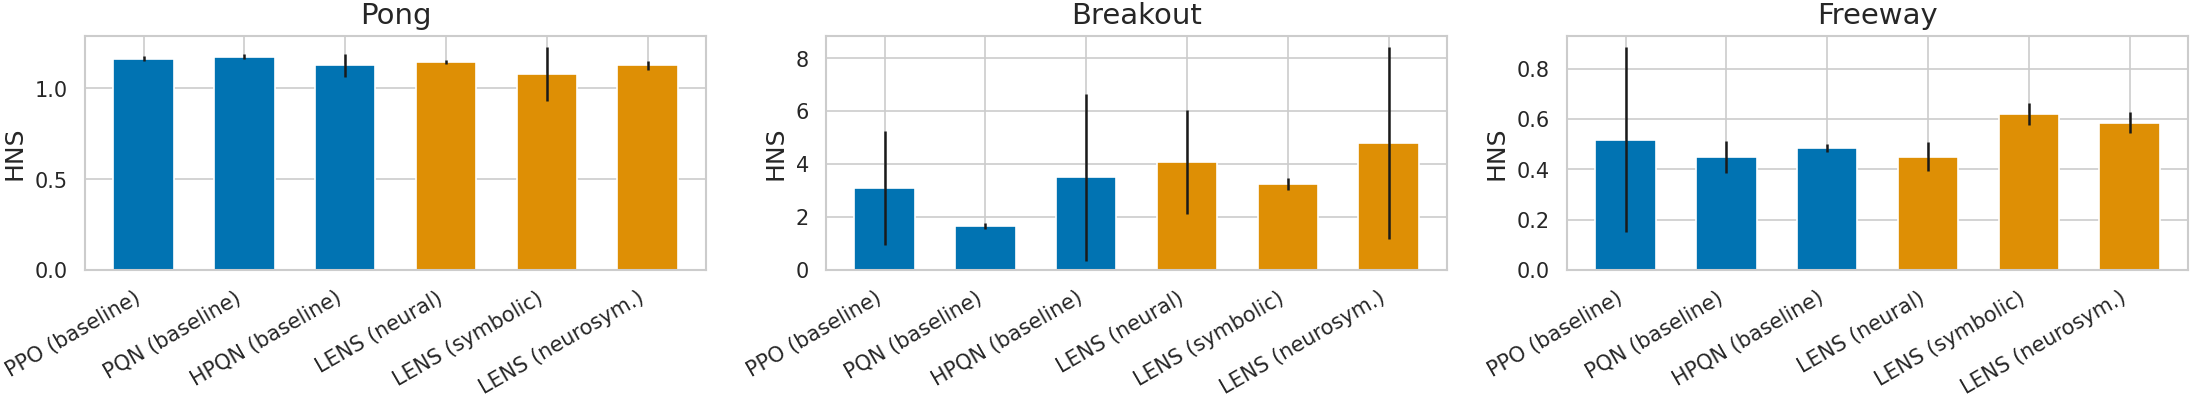

TypeError: 'Axes' object is not subscriptable

In [34]:
def single_metric_plot(df, game_name, algos, ax, modified=False):
    import seaborn as sns
    import numpy as np

    colors = sns.color_palette("colorblind")
    baselines = ["ppo", "pqn", "pqn_hier_baseline"]
    
    bar_colors = []
    for algo in algos:
        if algo in baselines:
            bar_colors.append(colors[0])
        else:
            bar_colors.append(colors[1])

    base_game = lambda g: g.split("_")[0].lower()
    random_score, human_score = human_random_performance[base_game(game_name)]

    hns_vals, hns_modif_vals = [], []
    hns_std, hns_modif_std = [], []

    for algo in algos:
        row = df[df["run_name"] == f"{algo.lower()}_{game_name.lower()}"].iloc[0]

        mean_ret = np.nanmean(row["test_env_ret"], axis=0)
        std_ret = np.nanstd(row["test_env_ret"], axis=0)
        max_idx = mean_ret.argmax()
        hns = (mean_ret[max_idx] - random_score) / (human_score - random_score + 1e-8)
        hns_std_val = std_ret[max_idx] / (human_score - random_score + 1e-8)

        mean_modif = np.nanmean(row["modif_test_env_ret"], axis=0)
        std_modif = np.nanstd(row["modif_test_env_ret"], axis=0)
        max_modif_idx = mean_modif.argmax()
        hns_modif = (mean_modif[max_modif_idx] - random_score) / (human_score - random_score + 1e-8)
        hns_modif_std_val = std_modif[max_modif_idx] / (human_score - random_score + 1e-8)

        hns_vals.append(hns)
        hns_modif_vals.append(hns_modif)
        hns_std.append(hns_std_val)
        hns_modif_std.append(hns_modif_std_val)

    if modified:
        hns_vals = hns_modif_vals
        hns_std = hns_modif_std

    x = np.arange(len(algos))
    ax.bar(x, hns_vals, yerr=hns_std, width=0.6, color=bar_colors)
    ax.set_ylabel("HNS")
    ax.set_xticks(x)
    ax.set_xticklabels([get_algorithm_from_name(a) for a in algos])
    ax.tick_params(axis='y')
    ax.set_ylim(bottom=0)
    ax.set_title(game_name)

    for label in ax.get_xticklabels():
        label.set_rotation(30)
        label.set_ha('right')

with plt.rc_context({
    **bundles.neurips2024(usetex=False),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 14,
    "font.size": 12
}):
    sns.set_style("whitegrid")
    fig, ax = plt.subplots(1, 3, figsize=(15, 3))
    single_metric_plot(pong_df, "Pong", ["ppo", "pqn", "pqn_hier_baseline", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb"], ax[0])
    single_metric_plot(breakout_df, "Breakout", ["ppo", "pqn", "pqn_hier_baseline", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb"], ax[1])
    single_metric_plot(freeway_df, "Freeway", ["ppo", "pqn", "pqn_hier_baseline", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb"], ax[2])
    handles, labels = ax[0].get_legend_handles_labels()
    plt.tight_layout()
    plt.savefig("comparison_single_metric.pdf", bbox_inches="tight")
    plt.show()

with plt.rc_context({
    **bundles.neurips2024(usetex=False),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 14,
    "font.size": 12
}):
    sns.set_style("whitegrid")
    fig, ax = plt.subplots(1, 1, figsize=(15, 3))
    single_metric_plot(craftax_df, "Craftax-Classic-Symbolic-v1", ["pqn_rnn", "pqn_rnn_hier_baseline", "pqn_rnn_hier", "pqn_rnn_hier_llm", "pqn_rnn_hier_comb"], ax)
    # single_metric_plot(breakout_df, "Breakout", ["ppo", "pqn", "pqn_hier_baseline", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb"], ax[1])
    # single_metric_plot(freeway_df, "Freeway", ["ppo", "pqn", "pqn_hier_baseline", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb"], ax[2])
    handles, labels = ax[0].get_legend_handles_labels()
    plt.tight_layout()
    plt.savefig("crafter_comparison_single_metric.pdf", bbox_inches="tight")
    plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


ppo 3.0000001192092896 3.0
pqn 3.00000007947286 2.0
pqn_hier_baseline 4.666666746139526 3.0
pqn_hier 6.0 3.6666666666666665
pqn_hier_llm 6.853444576263428 8.797731717427572
pqn_hier_comb 6.333333810170491 3.0


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


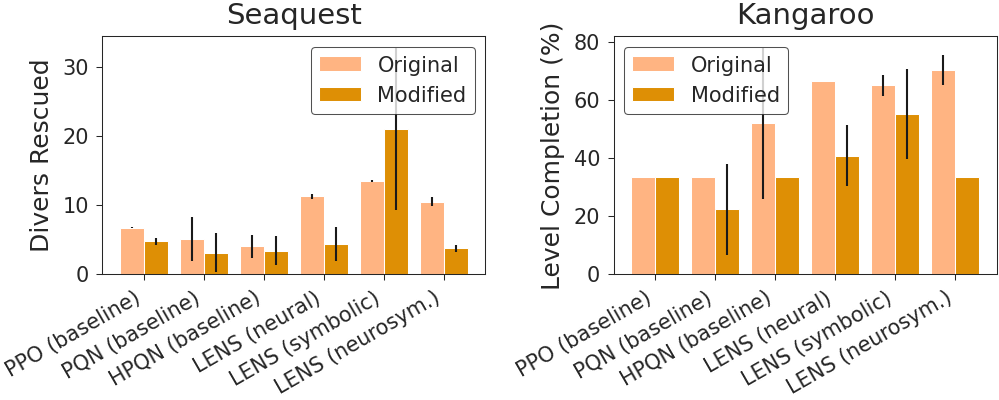

In [60]:
def aligned_performance_drop_plot(df, game_name, algos, ax):
    colors = sns.color_palette("colorblind")
    pastels = sns.color_palette("pastel")
    base_game = lambda g: g.split("_")[0].lower()
    random_score, human_score = human_random_performance[base_game(game_name)]

    hns_vals, comp_vals = [], []
    hns_modif_vals, comp_modif_vals = [], []
    hns_std, hns_modif_std, comp_std, comp_modif_std = [], [], [], []

    for i, algo in enumerate(algos):
        row = df[df["run_name"] == f"{algo.lower()}_{game_name.lower()}"].iloc[0]
        # HNS
        # find argmax of time step across all seeds (axis=0)
        mean_ret = np.nanmean(row["test_env_ret"], axis=0)
        std_ret = np.nanstd(row["test_env_ret"], axis=0)
        max_hns_idx = mean_ret.argmax()
        hns = (mean_ret[max_hns_idx] - random_score) / (human_score - random_score + 1e-8)
        hns_stds = std_ret[max_hns_idx] / (human_score - random_score + 1e-8)  # normalize by human score

        mean_modif = np.nanmean(row["modif_test_env_ret"], axis=0)
        std_modif = np.nanstd(row["modif_test_env_ret"], axis=0)
        # max_hns_modif_idx = mean_modif.argmax()
        max_hns_modif_idx = max_hns_idx
        hns_modif = (mean_modif[max_hns_modif_idx] - random_score) / (human_score - random_score + 1e-8)
        hns_modif_stds = std_modif[max_hns_modif_idx] / (human_score - random_score + 1e-8)  # normalize by human score
        hns_vals.append(hns)
        hns_modif_vals.append(hns_modif)
        hns_std.append(hns_stds)
        hns_modif_std.append(hns_modif_stds)

        if game_name == "Craftax-Classic-Symbolic-v1":
            comp = hns
            comp_stds = hns_stds
            comp_modif = hns_modif
            comp_modif_stds = hns_modif_stds


        # Completeness or Divers Rescued
        if game_name == "Kangaroo":
            mean_comp = np.nanmean(row["test_opt3_ret"], axis=0)
            std_comp = np.nanstd(row["test_opt3_ret"], axis=0)
            mean_modif_comp = np.nanmean(row["modif_test_opt3_ret"], axis=0)
            std_modif_comp = np.nanstd(row["modif_test_opt3_ret"], axis=0)
            max_comp_idx, max_modif_comp_idx = max_hns_idx , max_hns_idx
            # max_comp_idx = mean_comp.argmax()
            # max_modif_comp_idx = mean_modif_comp.argmax()
            comp = (mean_comp[max_comp_idx]/9)*100 #/3 (for lives), /3 (for 3 platform levels)
            comp_modif = (mean_modif_comp[max_modif_comp_idx]/9)*100
            print(algo, mean_comp[max_comp_idx], mean_modif_comp[max_modif_comp_idx])
            comp_stds = std_comp[max_comp_idx] / 9 *100
            comp_modif_stds = std_modif_comp[max_modif_comp_idx] / 9 *100

            def compute_corrected_std(all_max_comps):
                all_adjusted_comps = []
                for val in all_max_comps:
                    if val / 3 > 3:
                        platforms_level_2 = (val / 3) - 3
                        equiv = (platforms_level_2 / 6) / 3 # /3 for theoretical 3 platforms (of lvl1 equivalent platforms) in lvl2
                        adjusted = 100 + equiv*100 # as prob (not in %)
                        all_adjusted_comps.append(adjusted)
                    else:
                        all_adjusted_comps.append(val/9*100)
                print("all adjusted: ", all_adjusted_comps)
                comp_stds = np.std(all_adjusted_comps)
                return comp_stds

            # Correcting runs where platform is reached and then goes down ladder and back up -> artificially high values
            # Checked game footage for the following game finish percentages
            # checked all seeds (3 runs)
            if algo == "pqn_hier_llm":
                comp = (60+68+67) / 3 #reaches platform 2 in all 3 cases 
                comp_modif = (33+66+66)/3 #reaches platform 2 in 2 cases, else just 1
                comp_stds = np.std([60, 68, 67])
                comp_modif_stds = np.std([33, 66, 66]) 
            else: # all other runs look okay
                # It looks like it would also be the case for comb, but one of the seeds actually reaches level2 !!
                # so more than 100% is possible 
                # problem is that lvl 2 has 6 small platforms before reaching a level1 equivalent
                # so subtract 6, if reaching level 2
                if mean_comp[max_comp_idx] / 3 > 3: # reached lvl2 (/3 for num_lives)
                    platforms_level_2 = (mean_comp[max_comp_idx] / 3) - 3 #everything higher than the 3 lvl1 platforms (3 lives)
                    # divide by 6 to reach level1 equivalent (since 6 platforms in lvl2 equal 1 platform in lvl3)
                    equiv = (platforms_level_2 / 6) / 3 # /3 for theoretical 3 platforms (of lvl1 equivalent platforms) in lvl2
                    # 100 for lvl1 + x% for lvl2
                    comp = 100 + equiv * 100
                    all_max_comps = row["test_opt3_ret"][:, max_comp_idx]
                    comp_stds = compute_corrected_std(all_max_comps)

                if mean_modif_comp[max_modif_comp_idx] / 3 > 3:
                    platforms_level_2 = (mean_modif_comp[max_modif_comp_idx] / 3) - 3
                    # divide by 6 to reach level1 equivalent
                    equiv = (platforms_level_2 / 6) / 3 # /3 for theoretical 3 platforms (of lvl1 equivalent platforms) in lvl2
                    comp_modif = 100 + equiv * 100
                    all_max_modif_comps = row["modif_test_opt3_ret"][:, max_modif_comp_idx]
                    comp_modif_stds = compute_corrected_std(all_max_modif_comps)

        elif game_name == "Seaquest":
            mean_comp = np.nanmean(row["test_opt4_ret"], axis=0)
            std_comp = np.nanstd(row["test_opt4_ret"], axis=0)
            mean_modif_comp = np.nanmean(row["modif_test_opt4_ret"], axis=0)
            std_modif_comp = np.nanstd(row["modif_test_opt4_ret"], axis=0)
            # max_comp_idx = mean_comp.argmax()
            # max_modif_comp_idx = mean_modif_comp.argmax()
            max_comp_idx, max_modif_comp_idx = max_hns_idx , max_hns_idx
            comp = mean_comp[max_comp_idx]
            comp_modif = mean_modif_comp[max_modif_comp_idx]
            comp_stds = std_comp[max_comp_idx]
            comp_modif_stds = std_modif_comp[max_modif_comp_idx]
        comp_vals.append(comp)
        comp_modif_vals.append(comp_modif)
        comp_std.append(comp_stds)
        comp_modif_std.append(comp_modif_stds)

    # Plot Completeness / Divers
    ax.bar(np.arange(len(algos)) - 0.2, comp_vals, yerr=comp_std, width=0.4, 
            color=pastels[1])
    ax.bar(np.arange(len(algos)) + 0.2, comp_modif_vals, yerr=comp_modif_std, width=0.4, 
            color=colors[1])

    y_label = "HNS" if game_name == "Craftax-Classic-Symbolic-v1" else ("Level Completion (%)" if game_name == "Kangaroo" else "Divers Rescued")
    ax.set_ylabel(y_label)
    ax.set_xticks(np.arange(len(algos)))
    ax.set_xticklabels([get_algorithm_from_name(a) for a in algos])#, rotation=30, ha='right')
    # add legend
    ax.legend(["Original", "Modified"])

    ax.set_ylim(bottom=0)
    game_name = "Crafter" if game_name == "Craftax-Classic-Symbolic-v1" else game_name
    ax.set_title(game_name)
    
    for label in ax.get_xticklabels():
        label.set_rotation(30)
        label.set_ha('right')

with plt.rc_context({
    **bundles.neurips2024(usetex=False),
    **axes.lines(),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.size": 12
}):
    fig, ax = plt.subplots(1, 2, figsize=(7, 3))
    aligned_performance_drop_plot(seaquest_df, "Seaquest", ["ppo", "pqn", "pqn_hier_baseline","pqn_hier", "pqn_hier_llm", "pqn_hier_comb"], ax[0])
    aligned_performance_drop_plot(kangaroo_df, "Kangaroo", ["ppo", "pqn", "pqn_hier_baseline", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb"], ax[1])
    plt.tight_layout()
    plt.savefig("drop_plot.pdf", bbox_inches="tight")
    plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


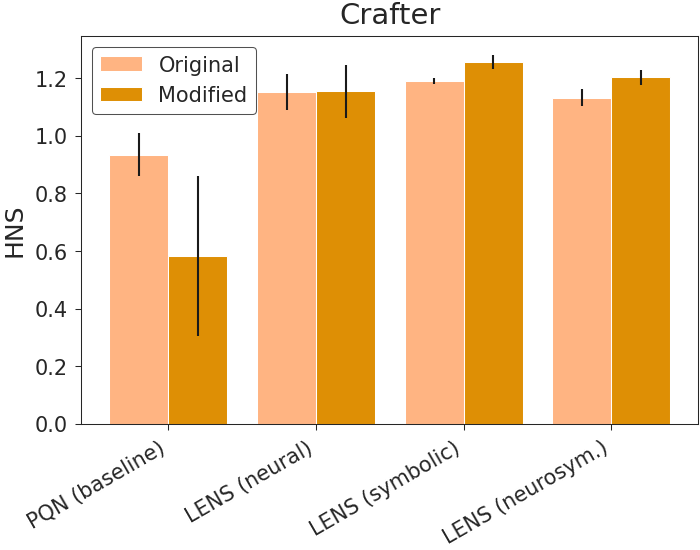

In [61]:
# same plots for crafter
with plt.rc_context({
    **bundles.neurips2024(usetex=False),
    **axes.lines(),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.size": 12
}):
    fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    aligned_performance_drop_plot(craftax_df, "Craftax-Classic-Symbolic-v1", ["pqn_rnn", "pqn_rnn_hier", "pqn_rnn_hier_llm", "pqn_rnn_hier_comb"], ax)
    plt.tight_layout()
    plt.savefig("drop_plot_crafter.pdf", bbox_inches="tight")
    plt.show()